# Regressão de preço de veículos com MLP

Este notebook implementa o trabalho de MLP para estimar `sellingprice` a partir das características e das informações de mercado dos veículos.

> **Integrantes:** Andrey de Matos Gonçalves, Felipe Gabriel Souza Libório, Felipe Vieira Brazão e Silva e Gabriel Coelho Goes.

## Declaração de uso de IA generativa

- **Ferramenta utilizada:** Codex, da OpenAI.
- **Finalidade:** apoiar a estruturação do notebook, a elaboração e revisão do código Python, a organização dos experimentos, a criação de tabelas e gráficos e a redação inicial das interpretações.
- **Extensão aproximada da contribuição:** contribuição substancial, estimada em aproximadamente dois terços da estruturação, do código e da redação inicial deste notebook. A escolha do tema, as decisões finais, a aceitação das alterações e a responsabilidade acadêmica permanecem com a equipe.


## Dataset escolhido e justificativa

- **Nome:** Vehicle Sales and Market Trends Dataset.
- **Fonte:** Kaggle, publicado por Syed Anwar Afridi.
- **Link:** <https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data>
- **Data de acesso/download:** 17/09/2026.
- **Tipo de problema:** regressão supervisionada.
- **Dimensão:** 558.837 instâncias e 16 colunas, correspondentes a 15 atributos preditores potenciais e 1 variável-alvo.
- **Variável-alvo:** `sellingprice`, valor final de venda do veículo, expresso em dólares americanos (US$).
- **Natureza e faixa observada do alvo:** variável numérica contínua, com valores entre US$ 1 e US$ 230.000.
- **Objetivo:** estimar o preço final de venda a partir das características do veículo, de seu estado de conservação e de informações de mercado disponíveis.

Os atributos originais descrevem o veículo (`year`, `make`, `model`, `trim`, `body`, `transmission`, `vin`, `condition`, `odometer`, `color` e `interior`) e o contexto da venda (`state`, `seller`, `mmr` e `saledate`). Durante o pré-processamento, removemos identificadores, variáveis de alta cardinalidade e atributos que poderiam antecipar o preço. A data de venda origina a idade do veículo.

O dataset foi escolhido por representar um problema real de regressão, possuir volume suficiente para o treinamento e a validação de uma MLP e combinar variáveis numéricas e categóricas, valores ausentes, escalas distintas e valores extremos. Essas características permitem aplicar e justificar as etapas de análise, pré-processamento, validação cruzada e ajuste de hiperparâmetros solicitadas na atividade. Além disso, ele não corresponde aos datasets utilizados em sala ou expressamente vedados na lauda.

## 1. Configuração e reprodutibilidade

A mesma semente é usada nas divisões e no TensorFlow. O conjunto de teste é separado antes de qualquer ajuste de pré-processamento ou hiperparâmetro.

In [1]:
from pathlib import Path
import random

import kagglehub

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow as tf
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

SEMENTE = 42
CAMINHOS_DADOS = [Path('data/raw/car_prices.csv'), Path('../data/raw/car_prices.csv'), Path('../../data/raw/car_prices.csv')]
CAMINHO_DADOS = next((caminho for caminho in CAMINHOS_DADOS if caminho.exists()), None)

if CAMINHO_DADOS is None:
    diretorio_kaggle = Path(kagglehub.dataset_download('syedanwarafridi/vehicle-sales-data'))
    CAMINHO_DADOS = next(diretorio_kaggle.rglob('car_prices.csv'), None)
    if CAMINHO_DADOS is None:
        raise FileNotFoundError(f'car_prices.csv não foi encontrado em {diretorio_kaggle}')
    print(f'Dataset baixado pelo Kaggle Hub: {CAMINHO_DADOS}')
else:
    print(f'Dataset local encontrado: {CAMINHO_DADOS}')
TEST_SIZE = 0.20
N_SPLITS_CV = 3
AMOSTRA_CV = 100_000  # reduz o custo da busca; sempre retirada somente do treino

random.seed(SEMENTE)
np.random.seed(SEMENTE)
tf.keras.utils.set_random_seed(SEMENTE)

print(f'Python/ambiente | scikit-learn={sklearn.__version__} | TensorFlow={tf.__version__}')

/home/liborio/cesupa/ml/machine-learning-mlp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-25 21:10:01.506339: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-25 21:10:01.548519: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-25 21:10:02.860500: I tensorflow/core/util/port.cc:153] oneDNN 

Dataset baixado pelo Kaggle Hub: /home/liborio/.cache/kagglehub/datasets/syedanwarafridi/vehicle-sales-data/versions/1/car_prices.csv
Python/ambiente | scikit-learn=1.5.2 | TensorFlow=2.19.1


## 2. Carregamento e diagnóstico inicial

O arquivo original não é alterado. A inspeção a seguir documenta dimensões, tipos, ausências e duplicatas para orientar o pré-processamento.

In [4]:
dados = pd.read_csv(CAMINHO_DADOS, low_memory=False)
print(f'Dimensões: {dados.shape[0]:,} linhas × {dados.shape[1]} colunas')
display(dados.head())
display(pd.DataFrame({
    'tipo': dados.dtypes.astype(str),
    'ausentes': dados.isna().sum(),
    'ausentes_%': (dados.isna().mean() * 100).round(2),
    'valores_unicos': dados.nunique(dropna=True),
}).sort_values('ausentes_%', ascending=False))
print(f'Duplicatas completas: {dados.duplicated().sum():,}')

Dimensões: 558,837 linhas × 16 colunas


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


,tipo,ausentes,ausentes_%,valores_unicos
transmission,str,65352,11.69,4
body,str,13195,2.36,87
condition,float64,11820,2.12,41
trim,str,10651,1.91,1963
model,str,10399,1.86,973
make,str,10301,1.84,96
color,str,749,0.13,46
interior,str,749,0.13,17
odometer,float64,94,0.02,172278
mmr,float64,38,0.01,1101


Duplicatas completas: 0


=== 1. Resumo de condition ===


,resultado
valores nulos,11820.000000
valores distintos,41.000000
mínimo,1.000000
máximo,49.000000
média,30.672365
mediana,35.000000
1º quartil (25%),23.000000
3º quartil (75%),42.000000


=== 2. Contagem completa de cada valor ===


,quantidade
condition,
1.0,7364
2.0,20790
3.0,10803
4.0,19922
5.0,11222
11.0,87
12.0,95
13.0,82
14.0,134


=== 3. Estatísticas por valor de condition ===


...

=== 4. Possíveis equivalências entre escalas ===


,quantidade_baixo,sellingprice_mediano_baixo,mmr_mediano_baixo,odometer_mediano_baixo,year_mediano_baixo,quantidade_alto,sellingprice_mediano_alto,mmr_mediano_alto,odometer_mediano_alto,year_mediano_alto
par,,,,,,,,,,
1 vs 10,7364,1700.0,3700.0,114498.5,2005.0,NaN,NaN,NaN,NaN,NaN
2 vs 20,20790,3700.0,4675.0,111274.5,2006.0,NaN,NaN,NaN,NaN,NaN
3 vs 30,10803,11700.0,12150.0,54218.0,2012.0,NaN,NaN,NaN,NaN,NaN
4 vs 40,19922,16500.0,16450.0,28041.0,2013.0,NaN,NaN,NaN,NaN,NaN
5 vs 50,11222,22100.0,21700.0,13943.5,2014.0,NaN,NaN,NaN,NaN,NaN


=== 5. Estatísticas por faixa de condition ===


,quantidade,condition_media,condition_mediana,year_mediano,odometer_mediano,sellingprice_medio,sellingprice_mediano,mmr_medio,mmr_mediano,diferenca_mediana,razao_mediana
faixa_condition,,,,,,,,,,,
1–5,70101.0,3.10,3.0,2012.0,42732.0,12986.89,11800.0,13606.76,12650.0,-250.0,0.98
10–19,43567.0,18.90,19.0,2006.0,117844.0,5053.80,3600.0,6094.70,4450.0,-750.0,0.83
20–29,111700.0,25.87,26.0,2008.0,88288.0,9263.68,8000.0,9781.47,8425.0,-400.0,0.95
30–39,161676.0,35.65,36.0,2012.0,53382.5,13939.80,12400.0,13914.75,12350.0,25.0,1.00
40–49,159973.0,44.28,44.0,2013.0,30783.5,19441.05,17200.0,19067.23,16850.0,300.0,1.02
50 ou mais,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== 6. Gráficos ===


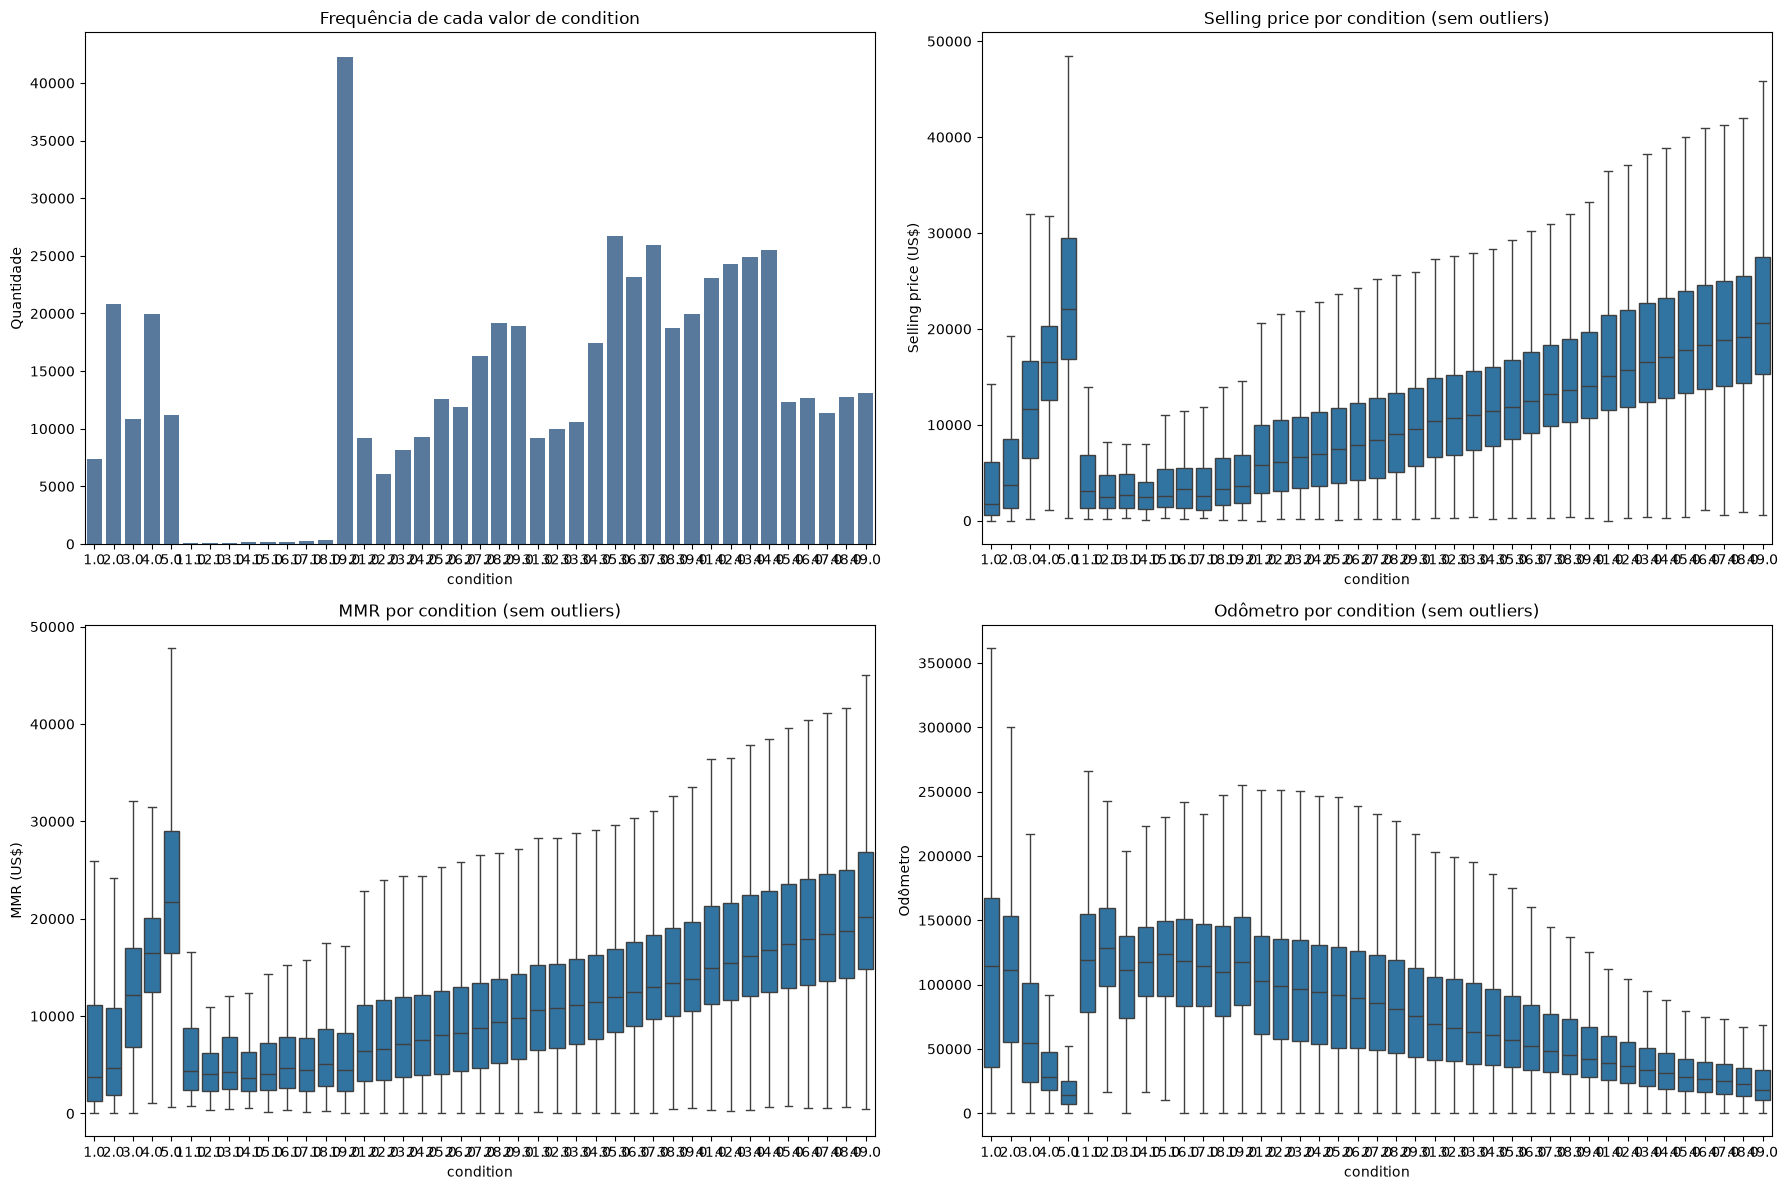

=== 7. Observações automáticas ===
• Há lacunas entre valores consecutivos: 5–11, 19–21, 29–31, 39–41.
• A frequência de condition=19 é 42,281, muito acima da mediana das frequências entre 10 e 18 (134).
• A relação entre condition e preço mediano parece monotônica crescente (Spearman=0.73).


In [5]:
# Investigação exploratória de possíveis escalas distintas em `condition`.
# Todas as transformações abaixo são feitas em cópias; `dados` não é alterado.
colunas_condition = ['condition', 'year', 'odometer', 'sellingprice', 'mmr']
dados_condition = dados[colunas_condition].copy()
serie_condition = dados_condition['condition']

print('=== 1. Resumo de condition ===')
resumo_condition = pd.DataFrame({'resultado': {
    'valores nulos': serie_condition.isna().sum(),
    'valores distintos': serie_condition.nunique(dropna=True),
    'mínimo': serie_condition.min(),
    'máximo': serie_condition.max(),
    'média': serie_condition.mean(),
    'mediana': serie_condition.median(),
    '1º quartil (25%)': serie_condition.quantile(.25),
    '3º quartil (75%)': serie_condition.quantile(.75),
}})
display(resumo_condition)

print('=== 2. Contagem completa de cada valor ===')
contagens_condition = serie_condition.value_counts(dropna=False).sort_index()
contagens_condition_sem_nulos = serie_condition.dropna().value_counts().sort_index()
display(contagens_condition.rename('quantidade').to_frame())

# Diferença e razão são calculadas linha a linha antes da agregação por condição.
dados_condition['dif_sellingprice_mmr'] = dados_condition['sellingprice'] - dados_condition['mmr']
dados_condition['razao_sellingprice_mmr'] = np.divide(
    dados_condition['sellingprice'], dados_condition['mmr'],
    out=np.full(len(dados_condition), np.nan),
    where=dados_condition['mmr'].notna() & dados_condition['mmr'].ne(0),
)

print('=== 3. Estatísticas por valor de condition ===')
tabela_condition = (
    dados_condition.dropna(subset=['condition'])
    .groupby('condition', sort=True)
    .agg(
        quantidade=('condition', 'size'),
        year_medio=('year', 'mean'), year_mediano=('year', 'median'),
        odometer_medio=('odometer', 'mean'), odometer_mediano=('odometer', 'median'),
        sellingprice_medio=('sellingprice', 'mean'), sellingprice_mediano=('sellingprice', 'median'),
        mmr_medio=('mmr', 'mean'), mmr_mediano=('mmr', 'median'),
        diferenca_mediana=('dif_sellingprice_mmr', 'median'),
        razao_mediana=('razao_sellingprice_mmr', 'median'),
    )
    .round(2)
)
display(tabela_condition)

print('=== 4. Possíveis equivalências entre escalas ===')
metricas_equivalencia = ['quantidade', 'sellingprice_mediano', 'mmr_mediano', 'odometer_mediano', 'year_mediano']
linhas_equivalencia = []
for valor_baixo, valor_alto in [(1, 10), (2, 20), (3, 30), (4, 40), (5, 50)]:
    linha = {'par': f'{valor_baixo} vs {valor_alto}'}
    for valor, sufixo in [(valor_baixo, 'baixo'), (valor_alto, 'alto')]:
        for metrica in metricas_equivalencia:
            linha[f'{metrica}_{sufixo}'] = tabela_condition.loc[valor, metrica] if valor in tabela_condition.index else np.nan
    linhas_equivalencia.append(linha)
comparacao_escalas = pd.DataFrame(linhas_equivalencia).set_index('par')
display(comparacao_escalas)

print('=== 5. Estatísticas por faixa de condition ===')
dados_faixas = dados_condition.copy()
dados_faixas['faixa_condition'] = np.select(
    [
        dados_faixas['condition'].between(1, 5),
        dados_faixas['condition'].between(10, 19),
        dados_faixas['condition'].between(20, 29),
        dados_faixas['condition'].between(30, 39),
        dados_faixas['condition'].between(40, 49),
        dados_faixas['condition'].ge(50),
    ],
    ['1–5', '10–19', '20–29', '30–39', '40–49', '50 ou mais'],
    default='fora das faixas',
)
ordem_faixas = ['1–5', '10–19', '20–29', '30–39', '40–49', '50 ou mais']
tabela_faixas = (
    dados_faixas.loc[dados_faixas['faixa_condition'].isin(ordem_faixas)]
    .groupby('faixa_condition', observed=True)
    .agg(
        quantidade=('condition', 'size'), condition_media=('condition', 'mean'), condition_mediana=('condition', 'median'),
        year_mediano=('year', 'median'), odometer_mediano=('odometer', 'median'),
        sellingprice_medio=('sellingprice', 'mean'), sellingprice_mediano=('sellingprice', 'median'),
        mmr_medio=('mmr', 'mean'), mmr_mediano=('mmr', 'median'),
        diferenca_mediana=('dif_sellingprice_mmr', 'median'), razao_mediana=('razao_sellingprice_mmr', 'median'),
    )
    .reindex(ordem_faixas)
    .round(2)
)
display(tabela_faixas)

print('=== 6. Gráficos ===')
ordem_condition = tabela_condition.index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(x=contagens_condition_sem_nulos.index, y=contagens_condition_sem_nulos.values, ax=axes[0, 0], color='#4C78A8')
axes[0, 0].set(title='Frequência de cada valor de condition', xlabel='condition', ylabel='Quantidade')
sns.boxplot(data=dados_condition, x='condition', y='sellingprice', order=ordem_condition, showfliers=False, ax=axes[0, 1])
axes[0, 1].set(title='Selling price por condition (sem outliers)', xlabel='condition', ylabel='Selling price (US$)')
sns.boxplot(data=dados_condition, x='condition', y='mmr', order=ordem_condition, showfliers=False, ax=axes[1, 0])
axes[1, 0].set(title='MMR por condition (sem outliers)', xlabel='condition', ylabel='MMR (US$)')
sns.boxplot(data=dados_condition, x='condition', y='odometer', order=ordem_condition, showfliers=False, ax=axes[1, 1])
axes[1, 1].set(title='Odômetro por condition (sem outliers)', xlabel='condition', ylabel='Odômetro')
plt.tight_layout()
plt.show()

print('=== 7. Observações automáticas ===')
valores_condition = np.array(ordem_condition, dtype=float)
lacunas = list(zip(valores_condition[:-1][np.diff(valores_condition) > 1], valores_condition[1:][np.diff(valores_condition) > 1]))
if lacunas:
    print('• Há lacunas entre valores consecutivos:', ', '.join(f'{int(a)}–{int(b)}' for a, b in lacunas) + '.')
else:
    print('• Não há lacunas entre os valores observados de condition.')

pares_disponiveis = [(a, b) for a, b in [(1, 10), (2, 20), (3, 30), (4, 40), (5, 50)] if a in tabela_condition.index and b in tabela_condition.index]
if pares_disponiveis:
    diferencas_pares = [
        abs(tabela_condition.loc[a, 'sellingprice_mediano'] - tabela_condition.loc[b, 'sellingprice_mediano']) / tabela_condition.loc[a, 'sellingprice_mediano']
        for a, b in pares_disponiveis if tabela_condition.loc[a, 'sellingprice_mediano'] != 0
    ]
    if diferencas_pares:
        diferenca_media = np.mean(diferencas_pares)
        conclusao = 'são semelhantes' if diferenca_media <= .15 else 'não são semelhantes'
        print(f'• Nos pares 1↔10 a 5↔50 disponíveis, a diferença média relativa do preço mediano é {diferenca_media:.1%}; as duas escalas {conclusao} por esse critério de 15%.')

freq_19 = contagens_condition.get(19, 0)
referencia_10_19 = contagens_condition.reindex(range(10, 19), fill_value=0).median()
if freq_19:
    rotulo_19 = 'muito acima' if referencia_10_19 and freq_19 >= 3 * referencia_10_19 else 'próxima'
    print(f'• A frequência de condition=19 é {freq_19:,}, {rotulo_19} da mediana das frequências entre 10 e 18 ({referencia_10_19:,.0f}).')
else:
    print('• O valor condition=19 não aparece no conjunto.')

precos_medianas = tabela_condition['sellingprice_mediano']
correlacao_medianas = precos_medianas.corr(pd.Series(precos_medianas.index, index=precos_medianas.index), method='spearman')
if abs(correlacao_medianas) >= .7:
    direcao = 'crescente' if correlacao_medianas > 0 else 'decrescente'
    print(f'• A relação entre condition e preço mediano parece monotônica {direcao} (Spearman={correlacao_medianas:.2f}).')
else:
    print(f'• A relação entre condition e preço mediano não parece fortemente monotônica (Spearman={correlacao_medianas:.2f}); escalas misturadas ou outros fatores podem estar influenciando.')

## 2.1 Distribuições das variáveis

Esta etapa descreve a distribuição geral das variáveis antes do pré-processamento. Para cada variável numérica, é apresentado um histograma com os valores ausentes removidos. Para cada variável categórica, são exibidas as contagens de cada categoria, incluindo valores ausentes; não são usados gráficos para essas variáveis.

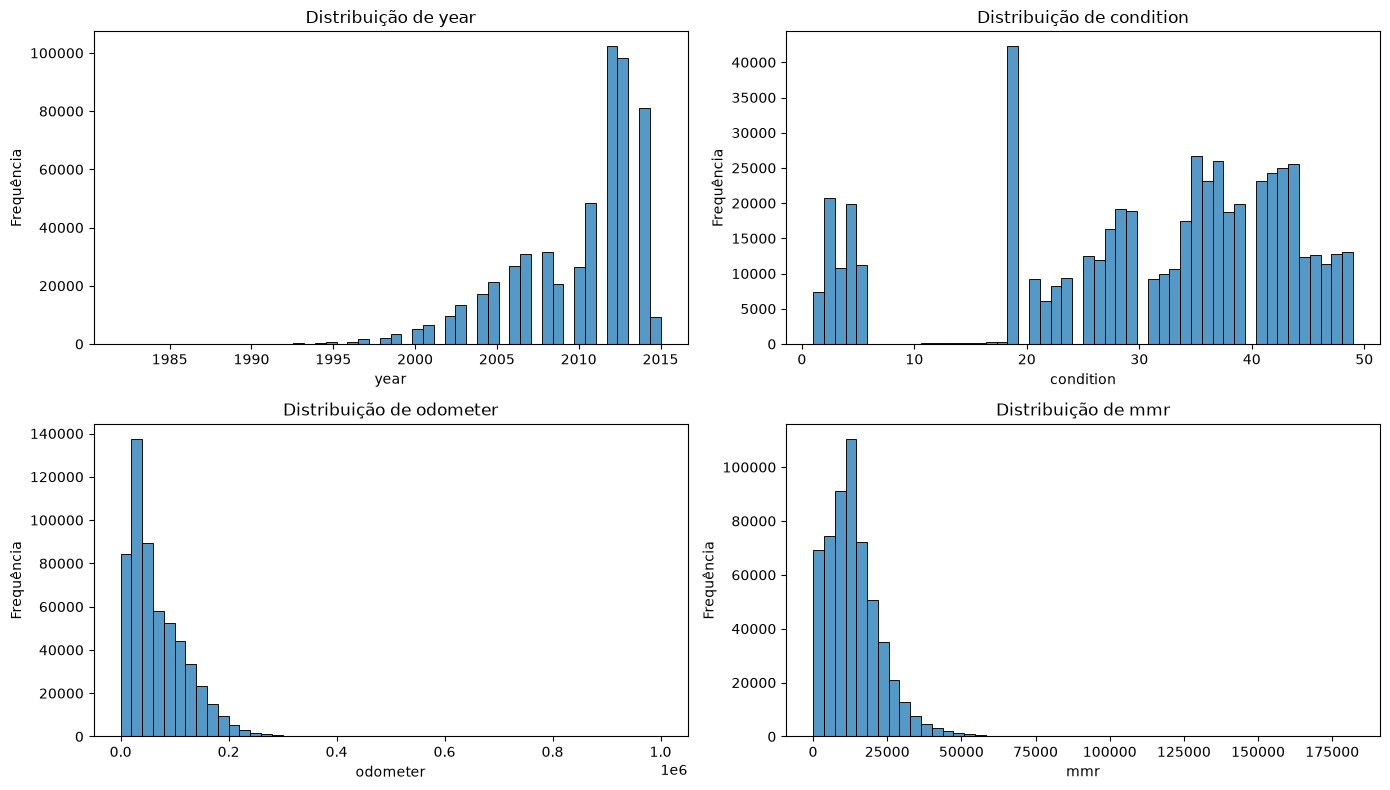


Contagem de valores: make


,quantidade
make,
Ford,93554
Chevrolet,60197
Nissan,53946
Toyota,39871
Dodge,30710
...,...
chev truck,1
ford tk,1
airstream,1



Contagem de valores: model


,quantidade
model,
Altima,19349
F-150,14479
Fusion,12946
Camry,12545
Escape,11861
...,...
Grand Cherokee SRT,1
Q3,1
360,1



Contagem de valores: trim


...

,quantidade
interior,
black,244329
gray,178581
beige,59758
tan,44093
—,17077
brown,8640
red,1363
blue,1143
silver,1104



Contagem de valores: seller


,quantidade
seller,
nissan-infiniti lt,19693
ford motor credit company llc,19162
the hertz corporation,18299
santander consumer,15285
avis corporation,12540
...,...
magnum motors llc,1
a-1 auto group llc,1
g brothers auto brokers inc,1



Contagem de valores: saledate


,quantidade
saledate,
Tue Feb 10 2015 01:30:00 GMT-0800 (PST),5334
Tue Feb 17 2015 01:30:00 GMT-0800 (PST),5016
Tue Jan 27 2015 01:30:00 GMT-0800 (PST),4902
Tue Jan 20 2015 01:30:00 GMT-0800 (PST),4731
Tue Mar 03 2015 01:30:00 GMT-0800 (PST),4653
...,...
Thu Jun 25 2015 07:10:00 GMT-0700 (PDT),1
Wed Jul 08 2015 09:05:00 GMT-0700 (PDT),1
Tue Jul 07 2015 08:45:00 GMT-0700 (PDT),1


In [3]:
# Variáveis numéricas: histogramas.
colunas_continuas = dados.select_dtypes(include=np.number).columns.drop('sellingprice').tolist()
n_colunas = 2
n_linhas = int(np.ceil(len(colunas_continuas) / n_colunas))
fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(14, 4 * n_linhas))
axes = np.atleast_1d(axes).ravel()

for eixo, coluna in zip(axes, colunas_continuas):
    sns.histplot(dados[coluna].dropna(), bins=50, ax=eixo)
    eixo.set(title=f'Distribuição de {coluna}', xlabel=coluna, ylabel='Frequência')

for eixo in axes[len(colunas_continuas):]:
    eixo.set_visible(False)

plt.tight_layout()
plt.show()

# Variáveis categóricas: contagens, sem gráficos.
colunas_categoricas = dados.select_dtypes(exclude=np.number).columns.tolist()
for coluna in colunas_categoricas:
    print(f'\nContagem de valores: {coluna}')
    display(dados[coluna].value_counts(dropna=False).rename('quantidade').to_frame())

## 3. Variável-alvo

Para regressão, serão usadas MAE como métrica principal, RMSE como penalização adicional para erros grandes e R² como proporção de variabilidade explicada. Antes do treinamento, verificamos a escala, dispersão e valores extremos de `sellingprice`.

,sellingprice
count,558825.000000
mean,13611.358810
std,9749.501628
min,1.000000
1%,500.000000
5%,1500.000000
50%,12100.000000
95%,30600.000000
99%,44900.000000
max,230000.000000


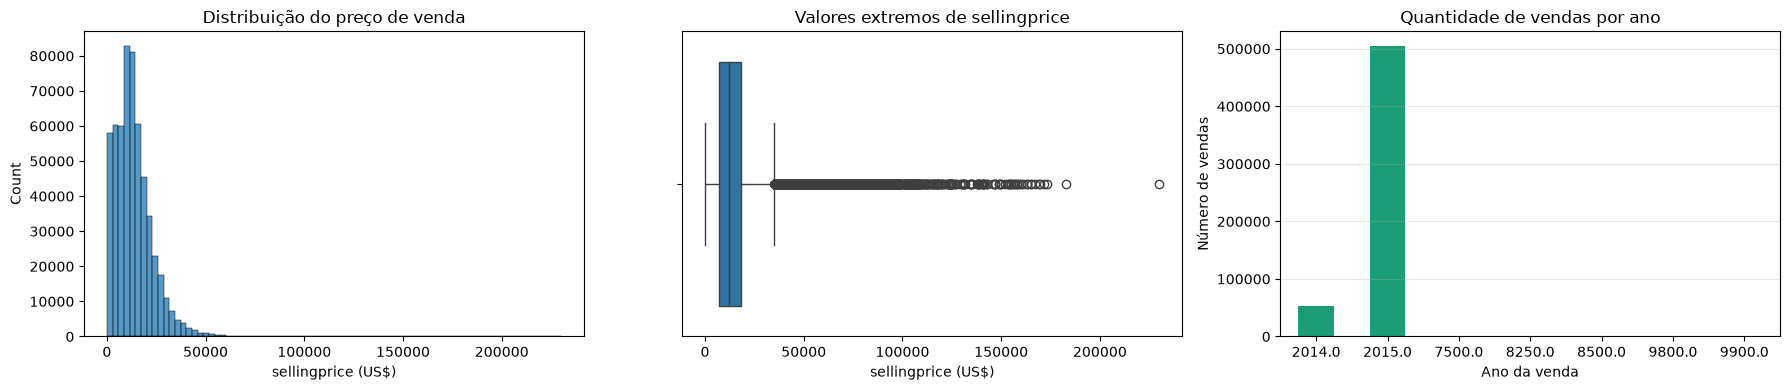

In [4]:
alvo = 'sellingprice'
display(dados[alvo].describe(percentiles=[.01, .05, .50, .95, .99]).to_frame('sellingprice'))

ano_venda_analise = pd.to_datetime(dados['saledate'], format='mixed', errors='coerce', utc=True).dt.year
vendas_por_ano = ano_venda_analise.value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(dados[alvo].dropna(), bins=80, ax=axes[0])
axes[0].set(title='Distribuição do preço de venda', xlabel='sellingprice (US$)')
sns.boxplot(x=dados[alvo].dropna(), ax=axes[1])
axes[1].set(title='Valores extremos de sellingprice', xlabel='sellingprice (US$)')
vendas_por_ano.plot.bar(ax=axes[2], color='#1b9e77')
axes[2].set(title='Quantidade de vendas por ano', xlabel='Ano da venda', ylabel='Número de vendas')
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Relação entre atributos numéricos e preço de venda

A correlação resume a associação linear (Pearson) e monotônica (Spearman) entre `sellingprice` e os atributos numéricos. Ela é uma análise exploratória: não estabelece causalidade e não mede diretamente a relação com variáveis categóricas.

O gráfico inclui `mmr` apenas para diagnóstico inicial. Essa variável continuará excluída da MLP por representar uma avaliação de mercado diretamente relacionada ao preço de venda.

,Pearson,Spearman
mmr,0.984,0.979
year,0.586,0.679
odometer,-0.582,-0.705
condition,0.322,0.480
idade_veiculo,-0.111,-0.676


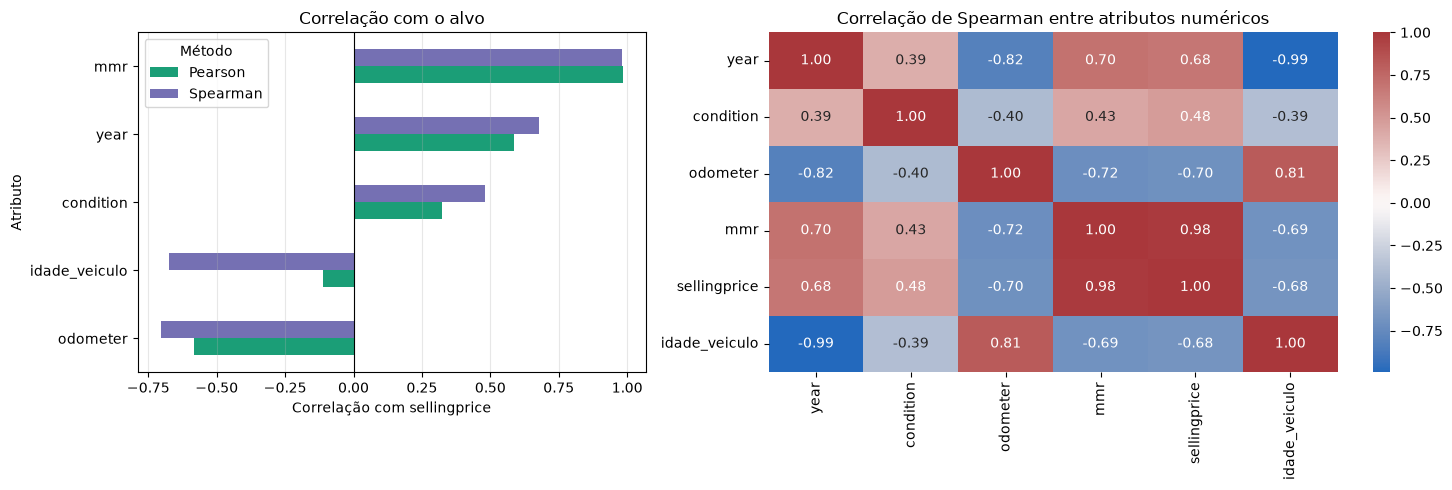

In [5]:
dados_analise = dados.copy()
ano_venda = pd.to_datetime(dados_analise['saledate'], format="mixed", errors="coerce", utc=True).dt.year
dados_analise['idade_veiculo'] = (ano_venda - dados_analise['year']).clip(lower=0)
dados_numericos = dados_analise.select_dtypes(include=np.number)
correlacoes = pd.DataFrame({
    "Pearson": dados_numericos.corr(method="pearson")[alvo],
    "Spearman": dados_numericos.corr(method="spearman")[alvo],
}).drop(index=alvo).sort_values("Pearson", key=np.abs, ascending=False)
display(correlacoes.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 1.4]})
correlacoes.sort_values("Pearson").plot.barh(ax=axes[0], color=["#1b9e77", "#7570b3"])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set(xlabel="Correlação com sellingprice", ylabel="Atributo", title="Correlação com o alvo")
axes[0].legend(title="Método")
axes[0].grid(axis="x", alpha=0.3)

sns.heatmap(dados_numericos.corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("Correlação de Spearman entre atributos numéricos")
plt.tight_layout()
plt.show()

### 3.2 Relação entre atributos categóricos e preço de venda

Para variáveis categóricas, a correlação numérica não é apropriada porque as categorias não possuem uma ordem natural. Nesta análise, `body` é normalizada localmente para remover espaços nas extremidades e diferenças entre maiúsculas e minúsculas, como `SUV` e `suv`. Em seguida, comparamos a quantidade de registros, a média e a mediana de `sellingprice` nas categorias mais frequentes de `make`, `body`, `color` e `interior`.

Os gráficos mostram somente as 12 categorias mais frequentes de cada atributo, incluindo a categoria `Ausente` quando aplicável. A mediana é usada como leitura principal por ser menos sensível aos valores extremos de preço.

,body_original,body_normalizado,quantidade
0,Access Cab,access cab,232
45,access cab,access cab,62
1,Beetle Convertible,beetle convertible,52
46,beetle convertible,beetle convertible,7
6,Cab Plus,cab plus,4
...,...,...,...
84,van,van,570
43,Wagon,wagon,13630
85,wagon,wagon,2499
44,Xtracab,xtracab,40


,categoria,quantidade,media,mediana,atributo
21,supercrew,9033,22098.39,23300.0,body
15,crew cab,16394,21649.05,21200.0,body
16,g sedan,7417,19943.21,20000.0,body
22,suv,143844,16115.92,15100.0,body
13,convertible,10476,17840.46,13900.0,body
14,coupe,17752,15927.82,13700.0,body
18,minivan,25529,11568.81,11400.0,body
20,supercab,5311,12777.93,11200.0,body
19,sedan,241332,11716.56,11000.0,body
17,hatchback,26237,10045.73,9900.0,body


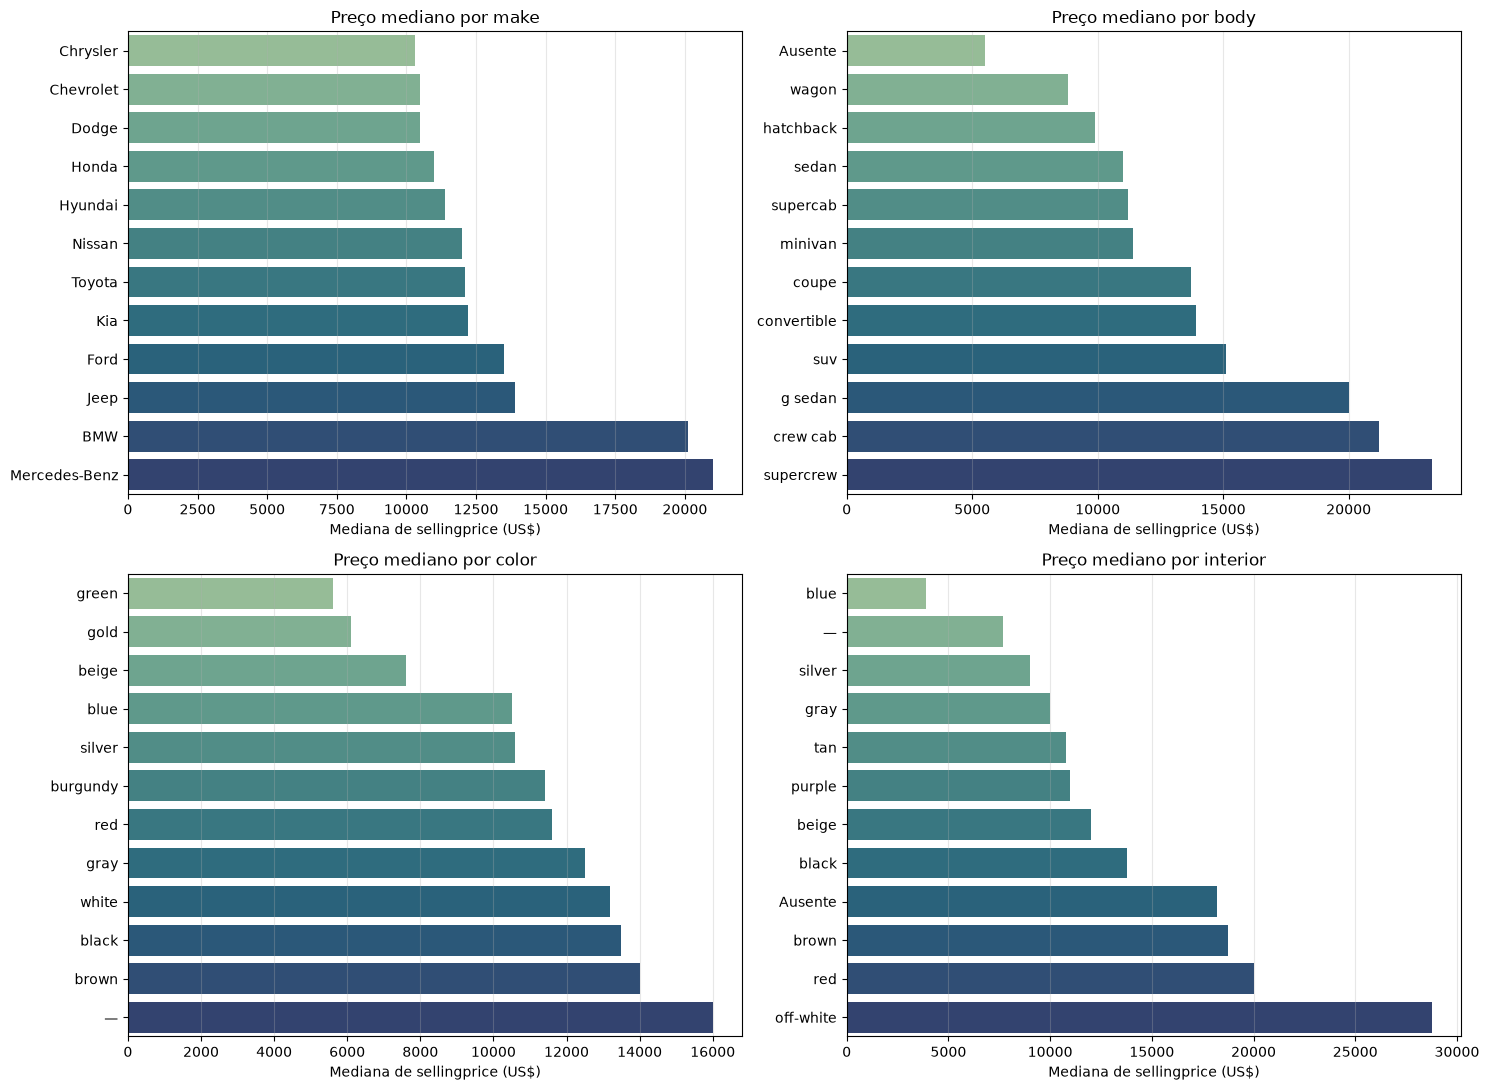

In [6]:
dados_categoricos = dados.copy()
dados_categoricos['body'] = dados_categoricos['body'].astype('string').str.strip().str.lower()
body_original = dados['body'].astype('string').str.strip()
diagnostico_body = (
    pd.DataFrame({"body_original": body_original, "body_normalizado": dados_categoricos['body']})
    .dropna()
    .groupby(["body_original", "body_normalizado"], as_index=False)
    .size()
    .rename(columns={"size": "quantidade"})
    .sort_values(["body_normalizado", "quantidade"], ascending=[True, False])
)
display(diagnostico_body)

CATEGORICAS_ANALISE = ["make", "body", "color", "interior"]
N_CATEGORIAS_GRAFICO = 12
resumos_categoricos = []

for coluna in CATEGORICAS_ANALISE:
    categorias = dados_categoricos[coluna].fillna("Ausente")
    categorias_frequentes = categorias.value_counts().head(N_CATEGORIAS_GRAFICO).index
    resumo = (
        pd.DataFrame({"categoria": categorias, "sellingprice": dados[alvo]})
        .loc[lambda tabela: tabela["categoria"].isin(categorias_frequentes)]
        .groupby("categoria", as_index=False)["sellingprice"]
        .agg(quantidade="count", media="mean", mediana="median")
        .assign(atributo=coluna)
    )
    resumos_categoricos.append(resumo)

resumo_categorias = pd.concat(resumos_categoricos, ignore_index=True)
display(resumo_categorias.sort_values(["atributo", "mediana"], ascending=[True, False]).round(2))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, coluna in zip(axes.flat, CATEGORICAS_ANALISE):
    dados_grafico = resumo_categorias.query("atributo == @coluna").sort_values("mediana")
    sns.barplot(data=dados_grafico, x="mediana", y="categoria", hue="categoria", legend=False, palette="crest", ax=ax)
    ax.set(title=f"Preço mediano por {coluna}", xlabel="Mediana de sellingprice (US$)", ylabel=None)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Perfil de preço, idade e uso por cor e interior

Os heatmaps comparam as categorias mais frequentes de `color` e `interior` usando quantidade de registros, odômetro mediano, idade mediana e preço de venda mediano. O fundo colorido mostra a posição relativa de cada categoria em cada métrica; os valores anotados permanecem nas unidades originais.

O marcador `—` e valores nulos são reunidos localmente como `desconhecida`, seguindo a decisão que será usada no pré-processamento. Esta é uma comparação agregada, portanto não isola o efeito de uma marca ou modelo específico.


As diferenças de preço mediano observadas para `color` e `interior` podem refletir outras características associadas, como idade, quilometragem, marca e modelo; portanto, elas não indicam que cor ou interior, isoladamente, causem variação no preço. Ainda assim, as duas variáveis serão mantidas no treinamento, pois podem acrescentar informação quando combinadas aos demais atributos. Sua contribuição efetiva poderá ser verificada futuramente por uma comparação controlada com e sem essas colunas.

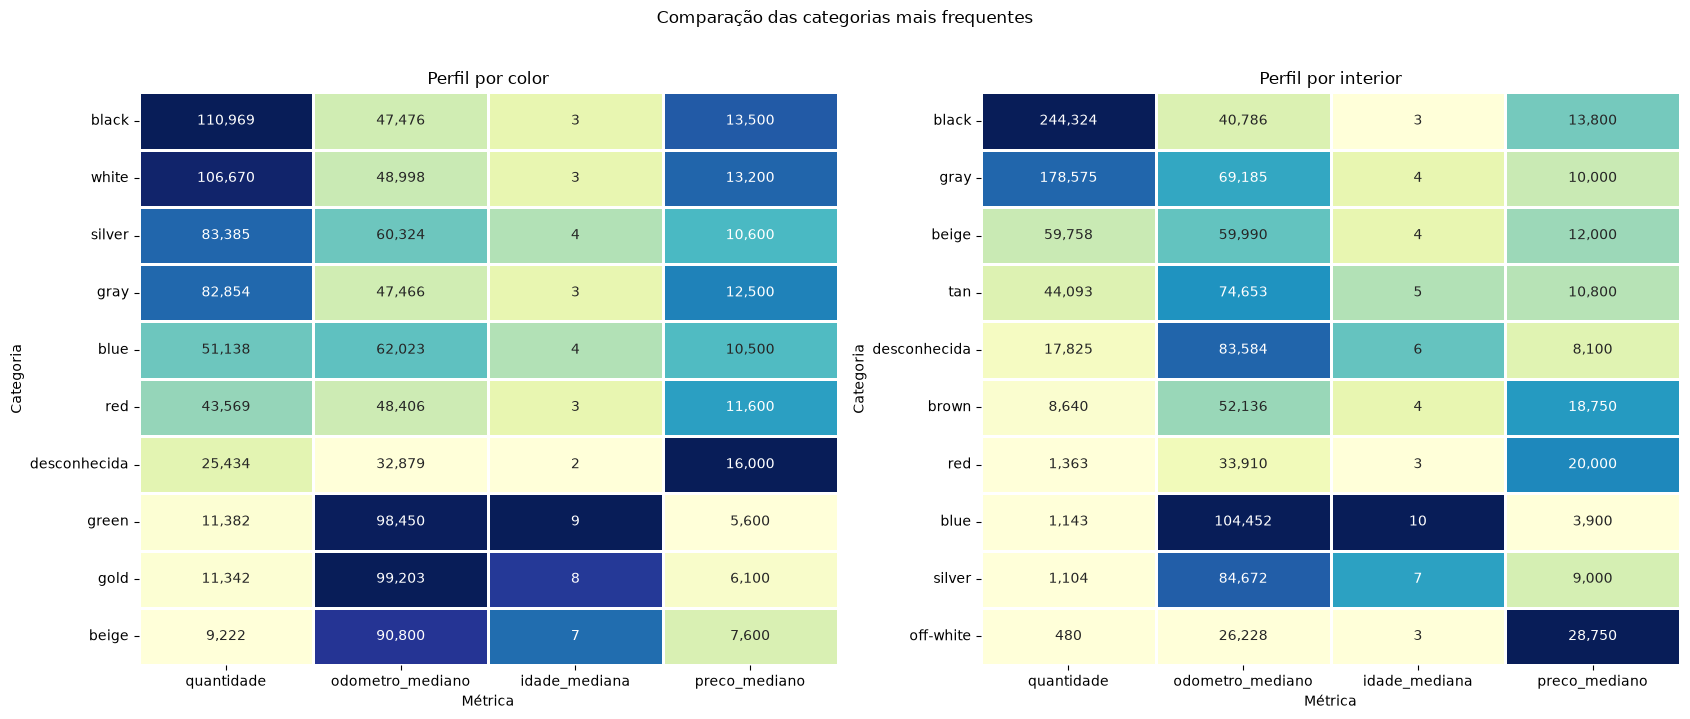

In [7]:
CATEGORIAS_HEATMAP = ["color", "interior"]
N_CATEGORIAS_HEATMAP = 10

dados_heatmap = dados.copy()
ano_venda_heatmap = pd.to_datetime(dados_heatmap["saledate"], format="mixed", errors="coerce", utc=True).dt.year
dados_heatmap["idade_veiculo"] = (ano_venda_heatmap - dados_heatmap["year"]).clip(lower=0)

resumos_heatmap = {}
for coluna in CATEGORIAS_HEATMAP:
    categorias = dados_heatmap[coluna].astype("string").str.strip().str.lower()
    categorias = categorias.replace("—", np.nan).fillna("desconhecida")
    categorias_frequentes = categorias.value_counts().head(N_CATEGORIAS_HEATMAP).index
    resumo = (
        pd.DataFrame({
            "categoria": categorias,
            "odometer": dados_heatmap["odometer"],
            "idade_veiculo": dados_heatmap["idade_veiculo"],
            "sellingprice": dados_heatmap[alvo],
        })
        .loc[lambda tabela: tabela["categoria"].isin(categorias_frequentes)]
        .groupby("categoria", as_index=True)
        .agg(
            quantidade=("sellingprice", "count"),
            odometro_mediano=("odometer", "median"),
            idade_mediana=("idade_veiculo", "median"),
            preco_mediano=("sellingprice", "median"),
        )
        .sort_values("quantidade", ascending=False)
    )
    resumos_heatmap[coluna] = resumo

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, coluna in zip(axes, CATEGORIAS_HEATMAP):
    tabela = resumos_heatmap[coluna]
    escala_relativa = (tabela - tabela.min()) / (tabela.max() - tabela.min()).replace(0, 1)
    anotacoes = tabela.copy().astype(object)
    anotacoes["quantidade"] = tabela["quantidade"].map(lambda valor: f"{valor:,.0f}")
    for metrica in ["odometro_mediano", "idade_mediana", "preco_mediano"]:
        anotacoes[metrica] = tabela[metrica].map(lambda valor: f"{valor:,.0f}")
    sns.heatmap(escala_relativa, annot=anotacoes, fmt="", cmap="YlGnBu", linewidths=0.8, linecolor="white", cbar=False, ax=ax)
    ax.set(title=f"Perfil por {coluna}", xlabel="Métrica", ylabel="Categoria")

fig.suptitle("Comparação das categorias mais frequentes", y=1.02)
plt.tight_layout()
plt.show()

## 4. Tratamento e preparação dos atributos

O tratamento é separado em limpeza e engenharia de atributos, seguida pela definição do pré-processamento usado pela MLP.

### 4.1 Limpeza e engenharia de atributos

`vin` é removido por ser quase único. `seller` fica fora da MLP por possuir alta cardinalidade, reduzindo dimensionalidade e o risco de memorizar vendedores. `mmr` é removida pois constitui uma avaliação de mercado diretamente relacionada ao preço de venda e poderia antecipar parte relevante do alvo. `transmission` é removida porque possui uma classe amplamente predominante, oferecendo pouca informação adicional à MLP. `saledate` não é descartada imediatamente: ela é convertida em data e usada, junto de `year`, para criar `idade_veiculo`; depois disso, `saledate`, `sale_year` e `year` são removidas para evitar atributos redundantes. Os textos são padronizados e o marcador `—` em cor e interior é tratado como ausente.

In [ ]:
def preparar_atributos(df):
    """Cria atributos determinísticos, sem ajustar estatísticas aos dados."""
    resultado = df.copy()
    data_venda = pd.to_datetime(resultado['saledate'], format='mixed', errors='coerce', utc=True)
    resultado['sale_year'] = data_venda.dt.year
    resultado['idade_veiculo'] = (resultado['sale_year'] - resultado['year']).clip(lower=0)
    resultado.loc[resultado['idade_veiculo'] > 100, 'idade_veiculo'] = np.nan
    colunas_texto = [
        coluna for coluna in resultado.select_dtypes(include=['object', 'string']).columns
        if coluna != 'saledate'
    ]
    for coluna in colunas_texto:
        texto_normalizado = resultado[coluna].astype('string').str.strip().str.lower()
        resultado[coluna] = texto_normalizado.astype(object).where(texto_normalizado.notna(), np.nan)
    for coluna in ['color', 'interior']:
        resultado[coluna] = resultado[coluna].replace('—', np.nan)
    resultado = resultado.drop(columns=['year', 'vin', 'saledate', 'sale_year', 'seller', 'mmr', 'transmission'])
    return resultado

dados_modelagem = dados.dropna(subset=[alvo]).copy()
X = preparar_atributos(dados_modelagem.drop(columns=alvo))
y = dados_modelagem[alvo].astype('float32')

### 4.2 Pré-processamento para a MLP

Atributos numéricos receberão imputação pela mediana e padronização. Os categóricos receberão `desconhecida` quando ausentes e serão convertidos por One-Hot Encoding, agrupando categorias raras. O pipeline é apenas definido aqui: seus parâmetros são ajustados exclusivamente nas partições de treino de cada fold, evitando vazamento para validação ou teste.

In [ ]:
# A escolha das colunas usa somente os tipos de dados; imputação, escala e codificação
# serão ajustadas mais adiante apenas nas partições de treino.
colunas_numericas = X.select_dtypes(include=np.number).columns.tolist()
colunas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessador = ColumnTransformer(
    transformers=[
        ('numericas', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('float32', FunctionTransformer(lambda x: x.astype(np.float32))),
        ]), colunas_numericas),
        ('categoricas', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='desconhecida')),
            ('onehot', OneHotEncoder(
                handle_unknown='infrequent_if_exist', min_frequency=100,
                max_categories=50, sparse_output=False, dtype=np.float32,
            )),
        ]), colunas_categoricas),
    ],
    remainder='drop',
)

print('Numéricas:', colunas_numericas)
print('Categóricas:', colunas_categoricas)

## 5. Divisão entre treino e teste

A separação reserva 20% dos dados para teste final e mantém 80% para treinamento, validação cruzada e busca de hiperparâmetros. Ela é estratificada por faixas de preço obtidas por quantis, preservando aproximadamente a distribuição do alvo no teste. O conjunto de teste não participa de nenhum ajuste antes da avaliação final.

In [ ]:
faixas_preco = pd.qcut(y, q=10, labels=False, duplicates='drop')
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEMENTE, stratify=faixas_preco
)
print(f'Treino: {X_treino.shape[0]:,} linhas | Teste reservado: {X_teste.shape[0]:,} linhas')
print('O conjunto de teste não será usado até a avaliação final.')

## 6. MLP de referência e validação cruzada

Antes das buscas, treinamos uma MLP de referência. Para que a busca posterior seja executável em CPU, a validação cruzada usa uma amostra estratificada de 100.000 observações retirada exclusivamente de `X_treino`. O conjunto de teste permanece intocado.

Como o preço possui escala ampla e assimetria, a rede aprende `log1p(sellingprice)`. As previsões são convertidas novamente para dólares antes do cálculo de MAE, RMSE e R².

In [10]:
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

def criar_mlp(n_entradas, camadas=(64, 32), ativacao='relu', learning_rate=1e-3, otimizador='adam'):
    """Cria uma MLP densa com saída linear para regressão."""
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEMENTE)
    modelo = tf.keras.Sequential([tf.keras.layers.Input(shape=(n_entradas,))])
    for neuronios in camadas:
        modelo.add(tf.keras.layers.Dense(neuronios, activation=ativacao))
    modelo.add(tf.keras.layers.Dense(1, activation='linear'))

    classe_otimizador = tf.keras.optimizers.get(otimizador).__class__
    modelo.compile(
        optimizer=classe_otimizador(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae'],
    )
    return modelo

CONFIG_REFERENCIA = {
    'camadas': (64, 32),
    'ativacao': 'relu',
    'learning_rate': 1e-3,
    'otimizador': 'adam',
    'batch_size': 128,
    'epocas': 80,
    'paciencia': 12,
}
CONFIG_REFERENCIA

{'camadas': (64, 32),
 'ativacao': 'relu',
 'learning_rate': 0.001,
 'otimizador': 'adam',
 'batch_size': 128,
 'epocas': 80,
 'paciencia': 12}

In [11]:
# Amostra estratificada retirada apenas do conjunto de treinamento.
if AMOSTRA_CV and AMOSTRA_CV < len(X_treino):
    faixas_treino = pd.qcut(y_treino, q=10, labels=False, duplicates='drop')
    X_cv, _, y_cv, _ = train_test_split(
        X_treino, y_treino, train_size=AMOSTRA_CV,
        random_state=SEMENTE, stratify=faixas_treino,
    )
else:
    X_cv, y_cv = X_treino.copy(), y_treino.copy()

print(f'Amostra para CV: {len(X_cv):,} linhas')

Amostra para CV: 100,000 linhas


In [12]:
def avaliar_configuracao_cv(configuracao, X_dados, y_dados, n_splits=N_SPLITS_CV, verbose=0, preprocessador_base=None):
    """Avalia uma configuração sem usar o holdout e retorna métricas em dólares."""
    if preprocessador_base is None:
        preprocessador_base = preprocessador
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=SEMENTE)
    resultados = []

    for fold, (idx_treino, idx_validacao) in enumerate(kfold.split(X_dados), start=1):
        X_fold_treino, X_fold_validacao = X_dados.iloc[idx_treino], X_dados.iloc[idx_validacao]
        y_fold_treino, y_fold_validacao = y_dados.iloc[idx_treino], y_dados.iloc[idx_validacao]

        # Validação interna para o EarlyStopping, separada do fold avaliado.
        faixas_internas = pd.qcut(y_fold_treino, q=10, labels=False, duplicates='drop')
        X_ajuste, X_parada, y_ajuste, y_parada = train_test_split(
            X_fold_treino, y_fold_treino, test_size=0.10,
            random_state=SEMENTE + fold, stratify=faixas_internas,
        )

        prep_fold = clone(preprocessador_base)
        X_ajuste_proc = prep_fold.fit_transform(X_ajuste)
        X_parada_proc = prep_fold.transform(X_parada)
        X_validacao_proc = prep_fold.transform(X_fold_validacao)

        modelo = criar_mlp(X_ajuste_proc.shape[1], **{
            chave: configuracao[chave]
            for chave in ['camadas', 'ativacao', 'learning_rate', 'otimizador']
        })
        parada = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=configuracao['paciencia'], restore_best_weights=True
        )
        parar_se_nan = tf.keras.callbacks.TerminateOnNaN()
        historico = modelo.fit(
            X_ajuste_proc, np.log1p(y_ajuste),
            validation_data=(X_parada_proc, np.log1p(y_parada)),
            epochs=configuracao['epocas'], batch_size=configuracao['batch_size'],
            callbacks=[parada, parar_se_nan], verbose=verbose,
        )
        # Evita overflow em expm1 se uma previsão em escala logarítmica for extrema.
        limite_log = np.log1p(y_ajuste.max() * 2)
        previsoes_log = modelo.predict(X_validacao_proc, verbose=0).ravel()
        previsoes_log = np.nan_to_num(previsoes_log, nan=0.0, posinf=limite_log, neginf=0.0)
        previsoes = np.expm1(np.clip(previsoes_log, 0.0, limite_log))
        resultados.append({
            'fold': fold,
            'mae': mean_absolute_error(y_fold_validacao, previsoes),
            'rmse': root_mean_squared_error(y_fold_validacao, previsoes),
            'r2': r2_score(y_fold_validacao, previsoes),
            'epocas_treinadas': len(historico.history['loss']),
        })

    return pd.DataFrame(resultados)

In [13]:
resultados_referencia = avaliar_configuracao_cv(CONFIG_REFERENCIA, X_cv, y_cv, verbose=0)
display(resultados_referencia)
resumo_referencia = resultados_referencia[['mae', 'rmse', 'r2', 'epocas_treinadas']].agg(['mean', 'std']).T
display(resumo_referencia)

,fold,mae,rmse,r2,epocas_treinadas
0,1,2696.494385,4602.888672,0.781437,36
1,2,2771.971680,4871.705566,0.752703,23
2,3,2701.072266,4560.678711,0.778714,35


,mean,std
mae,2723.179443,42.317265
rmse,4678.424316,168.711746
r2,0.770951,0.015862
epocas_treinadas,31.333333,7.234178


### Interpretação da referência

A MLP de referência obteve MAE médio de US$ 2.723,18 (desvio de US$ 42,32), RMSE de US$ 4.678,42 e R² de 0,7710. Ela treinou, em média, 31,3 épocas nos três folds. A pequena dispersão do MAE indica comportamento estável, enquanto a interrupção antes do limite de 80 épocas mostra que o Early Stopping encontrou um ponto de validação estável.

Essa referência serviu como ponto de partida: as buscas posteriores reduziram o MAE e elevaram o R², sem usar o conjunto de teste reservado.

## 7. Espaço comum de busca

Random Search e TPE usarão a mesma amostra `X_cv`, os mesmos 3 folds, o mesmo MAE como critério de seleção e o mesmo orçamento de 25 tentativas. O holdout continuará reservado até a configuração final.

## 8. Random Search — baseline

A função abaixo sorteia 25 configurações independentes. Não execute as duas buscas ao mesmo tempo: cada uma realiza 75 treinamentos (25 tentativas × 3 folds).

In [14]:
import gc
import optuna
from optuna.importance import get_param_importances

N_TRIALS = 25
ESPACO_BUSCA = {
    'n_camadas': [1, 2, 3], 'neuronios': [32, 64, 128, 256],
    'ativacao': ['relu', 'tanh'], 'learning_rate': (1e-4, 1e-2),
    'batch_size': [32, 64, 128], 'otimizador': ['adam', 'rmsprop'],
    'paciencia': [8, 12, 16, 20], 'epocas': 80,
}

def configurar_rede(parametros):
    camadas = tuple(parametros[f'neuronios_{i}'] for i in range(1, parametros['n_camadas'] + 1))
    return {
        'camadas': camadas, 'ativacao': parametros['ativacao'],
        'learning_rate': parametros['learning_rate'], 'otimizador': parametros['otimizador'],
        'batch_size': parametros['batch_size'], 'epocas': ESPACO_BUSCA['epocas'],
        'paciencia': parametros['paciencia'],
    }

def registrar_resultado(numero, parametros, folds):
    medias = folds[['mae', 'rmse', 'r2', 'epocas_treinadas']].mean().to_dict()
    return {
        'tentativa': numero, **parametros, 'camadas_efetivas': configurar_rede(parametros)['camadas'],
        **{f'{nome}_medio': valor for nome, valor in medias.items()},
        'mae_desvio': folds['mae'].std(),
    }

def sortear_parametros(rng):
    return {
        'n_camadas': int(rng.choice(ESPACO_BUSCA['n_camadas'])),
        'neuronios_1': int(rng.choice(ESPACO_BUSCA['neuronios'])),
        'neuronios_2': int(rng.choice(ESPACO_BUSCA['neuronios'])),
        'neuronios_3': int(rng.choice(ESPACO_BUSCA['neuronios'])),
        'ativacao': str(rng.choice(ESPACO_BUSCA['ativacao'])),
        'learning_rate': float(10 ** rng.uniform(-4, -2)),
        'batch_size': int(rng.choice(ESPACO_BUSCA['batch_size'])),
        'otimizador': str(rng.choice(ESPACO_BUSCA['otimizador'])),
        'paciencia': int(rng.choice(ESPACO_BUSCA['paciencia'])),
    }

def executar_random_search(n_trials=N_TRIALS):
    rng, registros = np.random.default_rng(SEMENTE), []
    for numero in range(1, n_trials + 1):
        parametros = sortear_parametros(rng)
        folds = avaliar_configuracao_cv(configurar_rede(parametros), X_cv, y_cv, verbose=0)
        registro = registrar_resultado(numero, parametros, folds)
        registros.append(registro)
        print(f"Random {numero:02d}/{n_trials}: MAE médio = US$ {registro['mae_medio']:,.2f}")
        gc.collect()
    return pd.DataFrame(registros).sort_values('mae_medio').reset_index(drop=True)

In [15]:
# Altere para True quando estiver pronto para executar os 25 trials.
EXECUTAR_RANDOM_SEARCH = True
if EXECUTAR_RANDOM_SEARCH:
    resultados_random = executar_random_search()
    display(resultados_random.head(10))
else:
    print('Random Search não executada. Defina EXECUTAR_RANDOM_SEARCH = True para iniciar.')

Random 01/25: MAE médio = US$ 2,910.65


Random 02/25: MAE médio = US$ 2,398.28


Random 03/25: MAE médio = US$ 2,909.34


Random 04/25: MAE médio = US$ 2,734.21


Random 05/25: MAE médio = US$ 2,880.77


...

Random 22/25: MAE médio = US$ 2,555.59


Random 23/25: MAE médio = US$ 2,610.12


Random 24/25: MAE médio = US$ 2,837.44


Random 25/25: MAE médio = US$ 2,555.17


,tentativa,n_camadas,neuronios_1,neuronios_2,neuronios_3,ativacao,learning_rate,batch_size,otimizador,paciencia,camadas_efetivas,mae_medio,rmse_medio,r2_medio,epocas_treinadas_medio,mae_desvio
0,20,3,128,128,64,tanh,0.000172,32,adam,20,"(128, 128, 64)",2383.376709,4259.574219,0.810265,63.000000,20.789381
1,2,2,256,128,256,tanh,0.000180,128,rmsprop,12,"(256, 128)",2398.276123,4331.061035,0.803778,80.000000,8.624310
2,14,2,128,32,128,tanh,0.000115,32,adam,12,"(128, 32)",2441.294678,4366.332520,0.800646,80.000000,25.838121
3,9,3,64,32,256,tanh,0.000421,128,rmsprop,20,"(64, 32, 256)",2474.539551,4465.024902,0.791487,74.333333,12.909076
4,15,3,32,64,64,tanh,0.000294,128,rmsprop,8,"(32, 64, 64)",2495.456787,4477.134277,0.790378,80.000000,55.792171
5,8,3,32,64,32,tanh,0.000284,64,rmsprop,16,"(32, 64, 32)",2507.219482,4555.164062,0.782936,72.333333,90.636169
6,11,3,32,256,32,tanh,0.002136,128,adam,16,"(32, 256, 32)",2509.264404,4540.748535,0.784374,48.000000,35.547958
7,25,1,128,32,128,tanh,0.000679,32,rmsprop,8,"(128,)",2555.168213,4631.424316,0.775673,80.000000,79.475128
8,22,1,128,256,64,tanh,0.000156,32,adam,20,"(128,)",2555.588867,4507.004395,0.787566,80.000000,27.883682
9,12,1,256,128,64,tanh,0.000190,64,adam,8,"(256,)",2561.387939,4532.069824,0.785197,80.000000,15.021101


In [16]:
def sugerir_parametros_tpe(trial):
    return {
        'n_camadas': trial.suggest_categorical('n_camadas', ESPACO_BUSCA['n_camadas']),
        'neuronios_1': trial.suggest_categorical('neuronios_1', ESPACO_BUSCA['neuronios']),
        'neuronios_2': trial.suggest_categorical('neuronios_2', ESPACO_BUSCA['neuronios']),
        'neuronios_3': trial.suggest_categorical('neuronios_3', ESPACO_BUSCA['neuronios']),
        'ativacao': trial.suggest_categorical('ativacao', ESPACO_BUSCA['ativacao']),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', ESPACO_BUSCA['batch_size']),
        'otimizador': trial.suggest_categorical('otimizador', ESPACO_BUSCA['otimizador']),
        'paciencia': trial.suggest_categorical('paciencia', ESPACO_BUSCA['paciencia']),
    }

def executar_tpe(n_trials=N_TRIALS):
    registros = []
    estudo = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEMENTE))
    def objetivo(trial):
        parametros = sugerir_parametros_tpe(trial)
        folds = avaliar_configuracao_cv(configurar_rede(parametros), X_cv, y_cv, verbose=0)
        registro = registrar_resultado(trial.number + 1, parametros, folds)
        registros.append(registro)
        trial.set_user_attr('rmse_medio', registro['rmse_medio'])
        trial.set_user_attr('r2_medio', registro['r2_medio'])
        print(f"TPE {trial.number + 1:02d}/{n_trials}: MAE médio = US$ {registro['mae_medio']:,.2f}")
        gc.collect()
        return registro['mae_medio']
    estudo.optimize(objetivo, n_trials=n_trials)
    return estudo, pd.DataFrame(registros).sort_values('mae_medio').reset_index(drop=True)

# O TPE deve ser executado depois da Random Search.
EXECUTAR_TPE = True
if EXECUTAR_TPE:
    estudo_tpe, resultados_tpe = executar_tpe()
    display(resultados_tpe.head(10))
else:
    print('TPE não executado. Defina EXECUTAR_TPE = True para iniciar.')

TPE 01/25: MAE médio = US$ 2,491.98


TPE 02/25: MAE médio = US$ 2,478.88


TPE 03/25: MAE médio = US$ 2,562.85


TPE 04/25: MAE médio = US$ 2,487.49


TPE 05/25: MAE médio = US$ 2,504.11


...

TPE 22/25: MAE médio = US$ 2,428.37


TPE 23/25: MAE médio = US$ 2,428.59


TPE 24/25: MAE médio = US$ 2,474.20


TPE 25/25: MAE médio = US$ 2,428.76


,tentativa,n_camadas,neuronios_1,neuronios_2,neuronios_3,ativacao,learning_rate,batch_size,otimizador,paciencia,camadas_efetivas,mae_medio,rmse_medio,r2_medio,epocas_treinadas_medio,mae_desvio
0,18,2,256,256,64,tanh,0.000283,128,adam,8,"(256, 256)",2428.012939,4296.856934,0.806883,64.666667,11.154925
1,22,2,256,256,64,tanh,0.000289,128,adam,8,"(256, 256)",2428.373535,4298.680176,0.806717,63.666667,10.516056
2,20,2,256,256,64,tanh,0.000287,128,adam,8,"(256, 256)",2428.576416,4299.118652,0.806678,63.666667,10.561307
3,23,2,256,256,64,tanh,0.000264,128,adam,8,"(256, 256)",2428.588135,4296.080078,0.806962,67.333333,13.154940
4,25,2,256,256,64,tanh,0.000250,128,adam,8,"(256, 256)",2428.762939,4292.966797,0.807246,70.333333,14.645637
5,24,2,256,256,64,tanh,0.000684,128,adam,8,"(256, 256)",2474.200928,4377.529785,0.799542,38.000000,20.620838
6,2,2,256,32,32,tanh,0.000329,32,adam,8,"(256, 32)",2478.883545,4428.706543,0.794892,35.000000,55.070488
7,15,2,128,32,128,tanh,0.000110,128,rmsprop,8,"(128, 32)",2483.540039,4531.846191,0.785206,80.000000,12.281222
8,4,1,128,32,128,relu,0.000112,128,rmsprop,8,"(128,)",2487.489502,4532.584473,0.785092,80.000000,14.479689
9,1,2,32,32,32,tanh,0.001121,128,rmsprop,16,"(32, 32)",2491.982422,4490.802734,0.788939,69.000000,55.885502


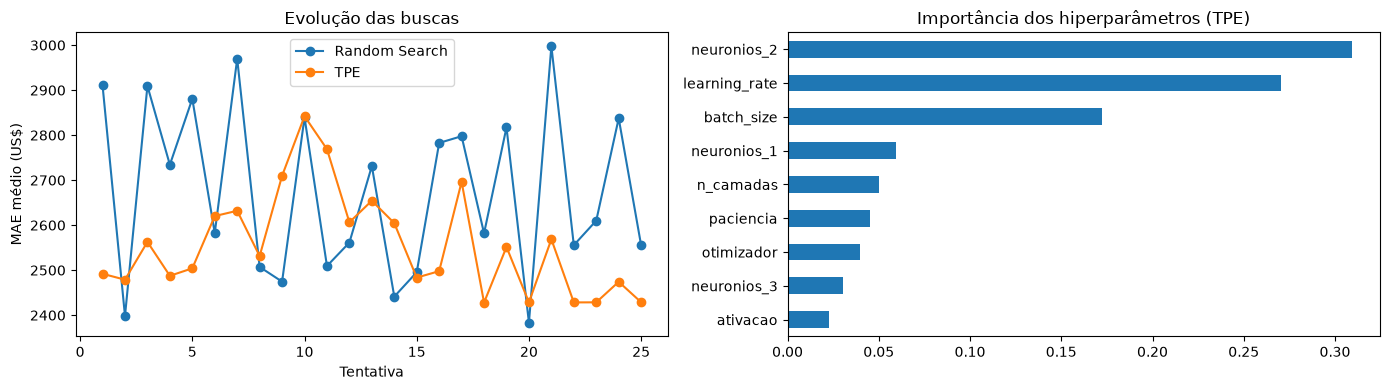

In [17]:
if 'resultados_random' in globals() and 'resultados_tpe' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for tabela, nome in [(resultados_random, 'Random Search'), (resultados_tpe, 'TPE')]:
        tabela = tabela.sort_values('tentativa')
        axes[0].plot(tabela['tentativa'], tabela['mae_medio'], marker='o', label=nome)
    axes[0].set(xlabel='Tentativa', ylabel='MAE médio (US$)', title='Evolução das buscas')
    axes[0].legend()
    pd.Series(get_param_importances(estudo_tpe)).sort_values().plot.barh(ax=axes[1])
    axes[1].set_title('Importância dos hiperparâmetros (TPE)')
    plt.tight_layout()
else:
    print('Execute as duas buscas antes de gerar a comparação.')

## 9. Comparação crítica entre Random Search e TPE

As duas estratégias usaram a mesma amostra de 100.000 registros do treino, três folds, MAE como critério e 25 configurações. O holdout permaneceu reservado.

| Estratégia | Melhor trial | Camadas | Ativação | Learning rate | Batch | Otimizador | Paciência | MAE médio (US$) | RMSE médio (US$) | R² médio |
|---|---:|---|---|---:|---:|---|---:|---:|---:|---:|
| **Random Search** | 20 | 128, 128, 64 | `tanh` | 0,000172 | 32 | Adam | 20 | **2.383,38** | **4.259,57** | **0,8103** |
| TPE | 18 | 256, 256 | `tanh` | 0,000283 | 128 | Adam | 8 | 2.428,01 | 4.296,86 | 0,8069 |

A Random Search encontrou a melhor configuração isolada, com MAE US$ 44,64 menor, cerca de 1,8%, e foi escolhida para o treinamento final. O TPE foi mais consistente no conjunto das tentativas: média de MAE de US$ 2.556,36 contra US$ 2.674,59 da busca aleatória, mediana de US$ 2.531,33 contra US$ 2.610,12 e menor dispersão entre trials.

A importância estimada pelo TPE destacou `neuronios_2` e `learning_rate`, seguidos por `batch_size`. Como a sensibilidade individual variou a primeira camada, e não `neuronios_2`, ela confirma diretamente o impacto de `learning_rate`, mas não testa de forma isolada o parâmetro mais importante estimado pelo TPE.

## 10. Análise de sensibilidade individual

Depois de escolher a melhor configuração, cada integrante varia um hiperparâmetro diferente em pelo menos cinco valores, mantendo os demais fixos. Todas as análises usam a mesma amostra de treinamento, os mesmos três folds e o MAE em dólares como métrica principal.

### 10.1 Andrey de Matos Gonçalves — taxa de aprendizado (`learning_rate`)

Esta análise investiga cinco ordens e níveis da taxa de aprendizado para observar o equilíbrio entre passos pequenos, convergência e instabilidade durante o treinamento.

learning_rate=0.0001: MAE médio = US$ 2,377.48


learning_rate=0.0003: MAE médio = US$ 2,412.69


learning_rate=0.001: MAE médio = US$ 2,523.54


learning_rate=0.003: MAE médio = US$ 2,687.53


learning_rate=0.01: MAE médio = US$ 2,853.58


,hiperparametro,valor,mae_medio,mae_desvio,rmse_medio,r2_medio
0,learning_rate,0.0001,2377.483154,24.895596,4241.950684,0.811835
1,learning_rate,0.0003,2412.686768,36.580891,4306.579102,0.806033
2,learning_rate,0.0010,2523.538574,30.126684,4524.937012,0.785800
3,learning_rate,0.0030,2687.528564,88.969406,4721.780762,0.766853
4,learning_rate,0.0100,2853.579102,63.673107,5052.092285,0.733099


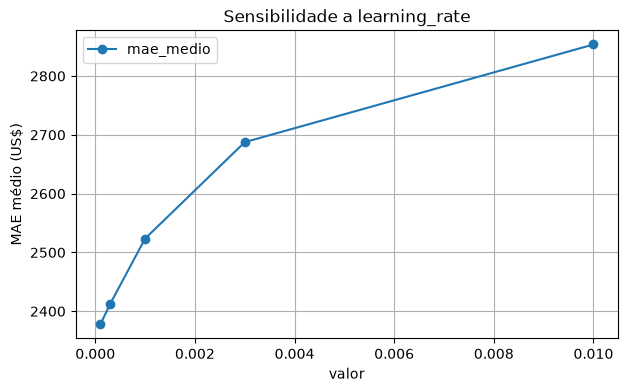

In [18]:
def obter_melhor_configuracao():
    tabelas = []
    if 'resultados_random' in globals():
        tabelas.append(resultados_random.assign(estrategia='Random Search'))
    if 'resultados_tpe' in globals():
        tabelas.append(resultados_tpe.assign(estrategia='TPE'))
    if not tabelas:
        raise RuntimeError('Execute Random Search e TPE antes de escolher a configuração final.')
    tabela = pd.concat(tabelas, ignore_index=True).sort_values('mae_medio')
    linha = tabela.iloc[0]
    parametros = {chave: linha[chave] for chave in ESPACO_BUSCA if chave not in {'epocas', 'neuronios'}}
    parametros.update({f'neuronios_{i}': int(linha[f'neuronios_{i}']) for i in range(1, 4)})
    parametros['n_camadas'] = int(linha['n_camadas'])
    parametros['batch_size'] = int(linha['batch_size'])
    parametros['paciencia'] = int(linha['paciencia'])
    return configurar_rede(parametros), linha

HIPERPARAMETRO = 'learning_rate'
VALORES = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
EXECUTAR_SENSIBILIDADE = True

def executar_sensibilidade(hiperparametro, valores):
    configuracao_base, linha_base = obter_melhor_configuracao()
    registros = []
    for valor in valores:
        configuracao = configuracao_base.copy()
        configuracao[hiperparametro] = valor
        folds = avaliar_configuracao_cv(configuracao, X_cv, y_cv, verbose=0)
        registros.append({
            'hiperparametro': hiperparametro, 'valor': valor,
            'mae_medio': folds['mae'].mean(), 'mae_desvio': folds['mae'].std(),
            'rmse_medio': folds['rmse'].mean(), 'r2_medio': folds['r2'].mean(),
        })
        print(f'{hiperparametro}={valor}: MAE médio = US$ {registros[-1]["mae_medio"]:,.2f}')
    return pd.DataFrame(registros), configuracao_base, linha_base

if EXECUTAR_SENSIBILIDADE:
    resultados_sensibilidade, configuracao_base, linha_base = executar_sensibilidade(HIPERPARAMETRO, VALORES)
    display(resultados_sensibilidade)
    resultados_sensibilidade.plot(x='valor', y='mae_medio', marker='o', figsize=(7, 4), title=f'Sensibilidade a {HIPERPARAMETRO}')
    plt.ylabel('MAE médio (US$)'); plt.grid(True); plt.show()
else:
    print('Sensibilidade não executada. Defina EXECUTAR_SENSIBILIDADE = True.')

#### Interpretação — Andrey de Matos Gonçalves

`learning_rate=1e-4` obteve o menor MAE, US$ 2.377,48. O erro aumentou progressivamente para US$ 2.412,69 em `3e-4`, US$ 2.523,54 em `1e-3`, US$ 2.687,53 em `3e-3` e US$ 2.853,58 em `1e-2`. A amplitude de US$ 476,10 foi a maior entre as sensibilidades realizadas, mostrando que passos de atualização maiores prejudicaram a convergência. O resultado é parcialmente coerente com o TPE, que atribuiu importância alta a `learning_rate`.

In [19]:
def executar_sensibilidade_personalizada(integrante, hiperparametro, valores, aplicar_valor):
    """Varia um único hiperparâmetro e mantém toda a configuração vencedora fixa."""
    configuracao_base, linha_base = obter_melhor_configuracao()
    registros = []
    for valor in valores:
        configuracao = configuracao_base.copy()
        configuracao['camadas'] = tuple(configuracao['camadas'])
        aplicar_valor(configuracao, valor)
        folds = avaliar_configuracao_cv(configuracao, X_cv, y_cv, verbose=0)
        registros.append({
            'integrante': integrante, 'hiperparametro': hiperparametro, 'valor': valor,
            'mae_medio': folds['mae'].mean(), 'mae_desvio': folds['mae'].std(),
            'rmse_medio': folds['rmse'].mean(), 'r2_medio': folds['r2'].mean(),
            'epocas_medias': folds['epocas_treinadas'].mean(),
        })
        print(f'{integrante} | {hiperparametro}={valor}: MAE médio = US$ {registros[-1]["mae_medio"]:,.2f}')
    return pd.DataFrame(registros), configuracao_base, linha_base

def exibir_sensibilidade(tabela, titulo, escala_log_x=False):
    display(tabela)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].errorbar(tabela['valor'], tabela['mae_medio'], yerr=tabela['mae_desvio'], marker='o', capsize=4)
    axes[0].set(xlabel='Valor testado', ylabel='MAE médio (US$)', title='Desempenho de validação')
    axes[1].plot(tabela['valor'], tabela['epocas_medias'], marker='o', color='#d95f02')
    axes[1].set(xlabel='Valor testado', ylabel='Épocas médias', title='Custo de treinamento')
    if escala_log_x:
        axes[0].set_xscale('log'); axes[1].set_xscale('log')
    for ax in axes:
        ax.grid(True, alpha=0.3)
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()

### 10.2 Felipe Gabriel Souza Libório — tamanho do lote (`batch_size`)

O tamanho do lote controla quantas observações contribuem para cada atualização dos pesos. Serão comparados cinco valores, mantendo fixa a configuração vencedora das buscas.

Felipe Gabriel Souza Libório | batch_size=16: MAE médio = US$ 2,393.76


Felipe Gabriel Souza Libório | batch_size=32: MAE médio = US$ 2,383.38


Felipe Gabriel Souza Libório | batch_size=64: MAE médio = US$ 2,386.46


Felipe Gabriel Souza Libório | batch_size=128: MAE médio = US$ 2,420.30


Felipe Gabriel Souza Libório | batch_size=256: MAE médio = US$ 2,456.07


,integrante,hiperparametro,valor,mae_medio,mae_desvio,rmse_medio,r2_medio,epocas_medias
0,Felipe Gabriel Souza Libório,batch_size,16,2393.762451,30.121191,4272.003906,0.809162,53.000000
1,Felipe Gabriel Souza Libório,batch_size,32,2383.376709,20.789381,4259.574219,0.810265,63.000000
2,Felipe Gabriel Souza Libório,batch_size,64,2386.460938,25.208958,4253.519531,0.810811,75.333333
3,Felipe Gabriel Souza Libório,batch_size,128,2420.301270,22.492741,4341.625000,0.802779,80.000000
4,Felipe Gabriel Souza Libório,batch_size,256,2456.073242,74.191757,4410.949219,0.796481,80.000000


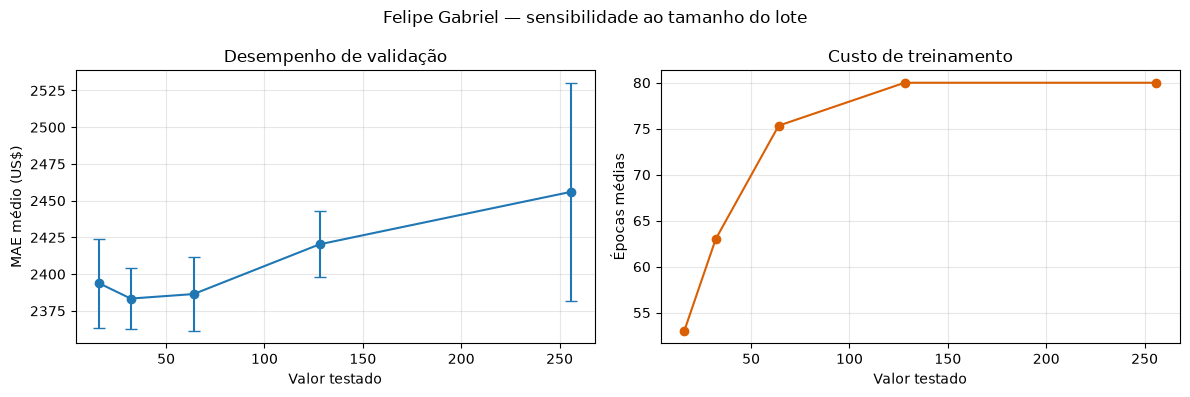

In [20]:
VALORES_BATCH_SIZE = [16, 32, 64, 128, 256]
resultados_sensibilidade_felipe_gabriel, _, _ = executar_sensibilidade_personalizada(
    'Felipe Gabriel Souza Libório', 'batch_size', VALORES_BATCH_SIZE,
    lambda configuracao, valor: configuracao.update(batch_size=valor),
)
exibir_sensibilidade(
    resultados_sensibilidade_felipe_gabriel,
    'Felipe Gabriel — sensibilidade ao tamanho do lote',
)

#### Interpretação — Felipe Gabriel Souza Libório

O menor MAE ocorreu com `batch_size=32`, US$ 2.383,38; `64` ficou praticamente empatado, com US$ 2.386,46 e o menor RMSE. Lotes de 128 e 256 pioraram o MAE para US$ 2.420,30 e US$ 2.456,07. Lotes maiores também chegaram com mais frequência ao limite de 80 épocas. Assim, o lote 32 apresentou o melhor resultado pelo critério principal, e o efeito de `batch_size` foi menor que o da taxa de aprendizado.

### 10.3 Felipe Vieira Brazão e Silva — neurônios na primeira camada oculta

Esta análise altera somente a largura da primeira camada oculta. As demais camadas e todos os outros hiperparâmetros permanecem iguais aos da melhor configuração encontrada.

Felipe Vieira Brazão e Silva | neuronios_primeira_camada=32: MAE médio = US$ 2,440.80


Felipe Vieira Brazão e Silva | neuronios_primeira_camada=64: MAE médio = US$ 2,410.78


Felipe Vieira Brazão e Silva | neuronios_primeira_camada=128: MAE médio = US$ 2,383.38


Felipe Vieira Brazão e Silva | neuronios_primeira_camada=256: MAE médio = US$ 2,395.19


Felipe Vieira Brazão e Silva | neuronios_primeira_camada=512: MAE médio = US$ 2,405.41


,integrante,hiperparametro,valor,mae_medio,mae_desvio,rmse_medio,r2_medio,epocas_medias
0,Felipe Vieira Brazão e Silva,neuronios_primeira_camada,32,2440.802734,31.319166,4401.473145,0.797351,76.000000
1,Felipe Vieira Brazão e Silva,neuronios_primeira_camada,64,2410.781250,22.424526,4337.772949,0.803241,70.000000
2,Felipe Vieira Brazão e Silva,neuronios_primeira_camada,128,2383.376709,20.789381,4259.574219,0.810265,63.000000
3,Felipe Vieira Brazão e Silva,neuronios_primeira_camada,256,2395.190674,28.173590,4290.824219,0.807448,48.333333
4,Felipe Vieira Brazão e Silva,neuronios_primeira_camada,512,2405.411865,32.370899,4310.858887,0.805679,43.000000


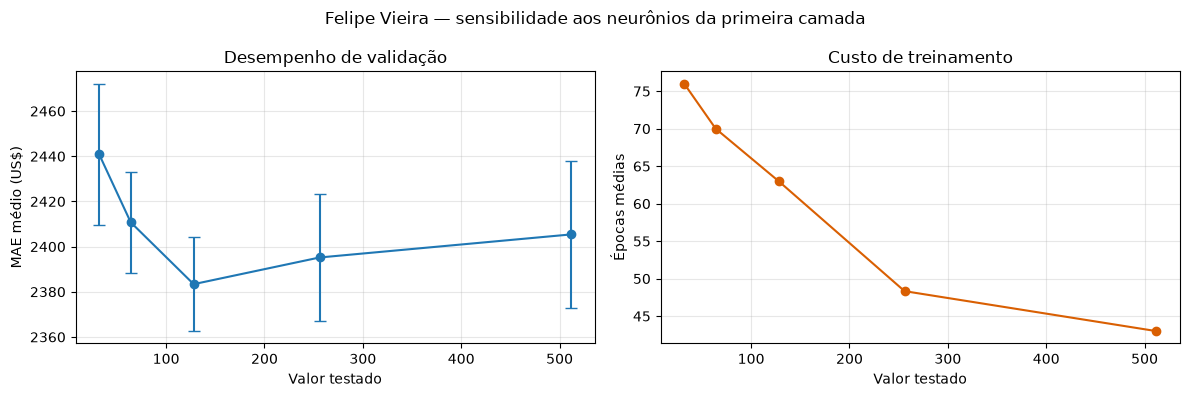

In [21]:
def alterar_primeira_camada(configuracao, valor):
    camadas = list(configuracao['camadas'])
    camadas[0] = valor
    configuracao['camadas'] = tuple(camadas)

VALORES_NEURONIOS_PRIMEIRA_CAMADA = [32, 64, 128, 256, 512]
resultados_sensibilidade_felipe_vieira, _, _ = executar_sensibilidade_personalizada(
    'Felipe Vieira Brazão e Silva', 'neuronios_primeira_camada',
    VALORES_NEURONIOS_PRIMEIRA_CAMADA, alterar_primeira_camada,
)
exibir_sensibilidade(
    resultados_sensibilidade_felipe_vieira,
    'Felipe Vieira — sensibilidade aos neurônios da primeira camada',
)

#### Interpretação — Felipe Vieira Brazão e Silva

A primeira camada com 128 neurônios obteve o menor MAE, US$ 2.383,38. Redes com 32 e 64 neurônios ficaram em US$ 2.440,80 e US$ 2.410,78; aumentar para 256 e 512 também não trouxe ganho, com US$ 2.395,19 e US$ 2.405,41. A amplitude de US$ 57,43 indica efeito moderado. Como o TPE destacou `neuronios_2`, este experimento não contradiz essa estimativa, pois avaliou apenas a largura da primeira camada.

### 10.4 Gabriel Coelho Goes — paciência do Early Stopping

A paciência determina quantas épocas sem melhora da perda de validação são toleradas antes da interrupção. Serão comparados cinco valores, mantendo os demais parâmetros fixos.

Gabriel Coelho Goes | paciencia=4: MAE médio = US$ 2,386.18


Gabriel Coelho Goes | paciencia=8: MAE médio = US$ 2,383.38


Gabriel Coelho Goes | paciencia=12: MAE médio = US$ 2,383.38


Gabriel Coelho Goes | paciencia=16: MAE médio = US$ 2,383.38


Gabriel Coelho Goes | paciencia=20: MAE médio = US$ 2,383.38


,integrante,hiperparametro,valor,mae_medio,mae_desvio,rmse_medio,r2_medio,epocas_medias
0,Gabriel Coelho Goes,paciencia,4,2386.182129,17.676378,4269.350098,0.809388,44.666667
1,Gabriel Coelho Goes,paciencia,8,2383.376709,20.789381,4259.574219,0.810265,51.000000
2,Gabriel Coelho Goes,paciencia,12,2383.376709,20.789381,4259.574219,0.810265,55.000000
3,Gabriel Coelho Goes,paciencia,16,2383.376709,20.789381,4259.574219,0.810265,59.000000
4,Gabriel Coelho Goes,paciencia,20,2383.376709,20.789381,4259.574219,0.810265,63.000000


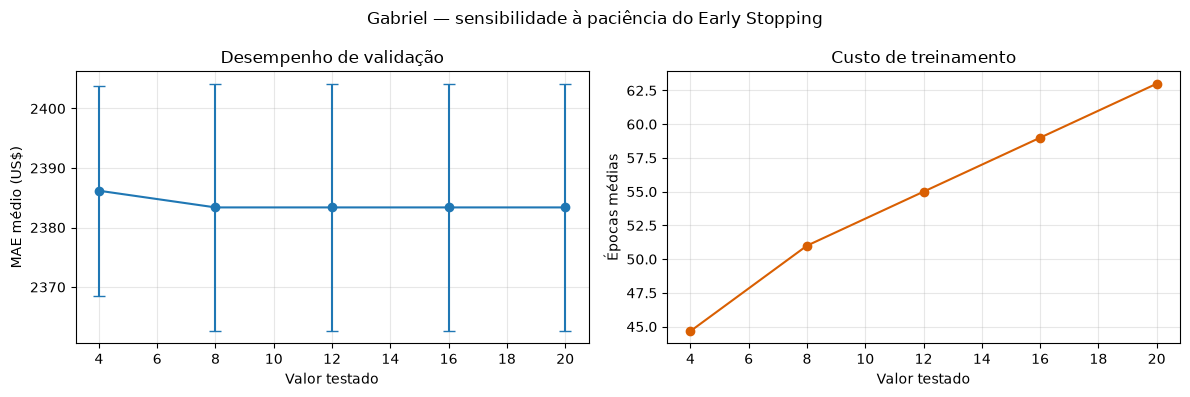

In [22]:
VALORES_PACIENCIA = [4, 8, 12, 16, 20]
resultados_sensibilidade_gabriel, _, _ = executar_sensibilidade_personalizada(
    'Gabriel Coelho Goes', 'paciencia', VALORES_PACIENCIA,
    lambda configuracao, valor: configuracao.update(paciencia=valor),
)
exibir_sensibilidade(
    resultados_sensibilidade_gabriel,
    'Gabriel — sensibilidade à paciência do Early Stopping',
)

#### Interpretação — Gabriel Coelho Goes

As paciências 8, 12, 16 e 20 produziram o mesmo MAE, US$ 2.383,38, e as mesmas métricas de validação. Com paciência 4, o MAE foi levemente maior, US$ 2.386,18. Entre os valores empatados, 8 foi mais econômico, com 51 épocas médias, contra 55, 59 e 63 para 12, 16 e 20. Portanto, a paciência teve impacto quase nulo no desempenho e afetou principalmente o tempo de treinamento.

## 11. Decisões sobre os atributos

O modelo não utiliza `vin`, `seller`, `mmr` nem `transmission`. `vin` é praticamente um identificador único; `seller` possui alta cardinalidade; `mmr` é uma avaliação prévia de mercado muito próxima do preço de venda; e `transmission` foi excluída nesta versão para reduzir atributos categóricos. A informação temporal de `saledate` é usada para criar `idade_veiculo = sale_year - year`, uma variável numérica mais diretamente relacionada à depreciação do veículo.

Essas decisões são aplicadas antes da separação entre treino e teste e permanecem iguais em todas as buscas e análises de sensibilidade.

In [23]:
atributos_excluidos = ['vin', 'seller', 'mmr', 'transmission', 'saledate']
display(pd.DataFrame({
    'atributo': atributos_excluidos,
    'decisao': ['removido'] * len(atributos_excluidos),
}))
print('Atributos usados pela MLP:', X.columns.tolist())

,atributo,decisao
0,vin,removido
1,seller,removido
2,mmr,removido
3,transmission,removido
4,saledate,removido


Atributos usados pela MLP: ['make', 'model', 'trim', 'body', 'state', 'condition', 'odometer', 'color', 'interior', 'idade_veiculo']


A exclusão de `mmr` evita que a MLP dependa de uma estimativa de mercado pronta. A inclusão de `idade_veiculo` preserva a informação temporal relevante de forma interpretável. Essas decisões permaneceram fixas em todas as buscas, sensibilidades e na avaliação final.

## 12. Treinamento final e teste reservado

A configuração com menor MAE médio é treinada novamente usando somente os dados de treino. O conjunto de teste é transformado e avaliado uma única vez nesta etapa final.

In [24]:
EXECUTAR_AVALIACAO_FINAL = True

def treinar_e_avaliar_final():
    configuracao, linha_base = obter_melhor_configuracao()
    faixas = pd.qcut(y_treino, q=10, labels=False, duplicates='drop')
    X_ajuste, X_parada, y_ajuste, y_parada = train_test_split(
        X_treino, y_treino, test_size=0.10, random_state=SEMENTE, stratify=faixas
    )
    prep_final = clone(preprocessador)
    X_ajuste_proc = prep_final.fit_transform(X_ajuste)
    X_parada_proc = prep_final.transform(X_parada)
    X_teste_proc = prep_final.transform(X_teste)
    modelo_final = criar_mlp(X_ajuste_proc.shape[1], **{
        chave: configuracao[chave] for chave in ['camadas', 'ativacao', 'learning_rate', 'otimizador']
    })
    historico_final = modelo_final.fit(
        X_ajuste_proc, np.log1p(y_ajuste), validation_data=(X_parada_proc, np.log1p(y_parada)),
        epochs=configuracao['epocas'], batch_size=configuracao['batch_size'],
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=configuracao['paciencia'], restore_best_weights=True), tf.keras.callbacks.TerminateOnNaN()],
        verbose=0,
    )
    limite_log = np.log1p(y_ajuste.max() * 2)
    previsoes_log = np.nan_to_num(modelo_final.predict(X_teste_proc, verbose=0).ravel(), nan=0.0, posinf=limite_log, neginf=0.0)
    previsoes = np.expm1(np.clip(previsoes_log, 0.0, limite_log))
    metricas = pd.Series({
        'MAE (US$)': mean_absolute_error(y_teste, previsoes),
        'RMSE (US$)': root_mean_squared_error(y_teste, previsoes),
        'R²': r2_score(y_teste, previsoes),
        'épocas treinadas': len(historico_final.history['loss']),
    })
    return modelo_final, metricas, linha_base, previsoes, historico_final

if EXECUTAR_AVALIACAO_FINAL:
    modelo_final, metricas_finais, melhor_linha, previsoes_teste, historico_final = treinar_e_avaliar_final()
    display(metricas_finais.to_frame('resultado'))
else:
    print('Avaliação final não executada. Defina EXECUTAR_AVALIACAO_FINAL = True somente após a sensibilidade.')

,resultado
MAE (US$),2083.086670
RMSE (US$),3646.979004
R²,0.858886
épocas treinadas,49.000000


## 13. Diagnóstico de overfitting e underfitting

As curvas abaixo usam apenas o subconjunto de ajuste e a validação interna criada dentro do conjunto de treino. O holdout de teste não foi usado para escolher a época. Como o modelo aprende `log1p(sellingprice)`, as perdas desta seção estão na escala logarítmica; as métricas finais em dólares permanecem na seção anterior.

,resultado
épocas treinadas,49.000000
melhor época pela perda de validação,29.000000
MSE treino na melhor época,0.103906
MSE validação na melhor época,0.114059
MAE log treino na melhor época,0.202231
MAE log validação na melhor época,0.207855


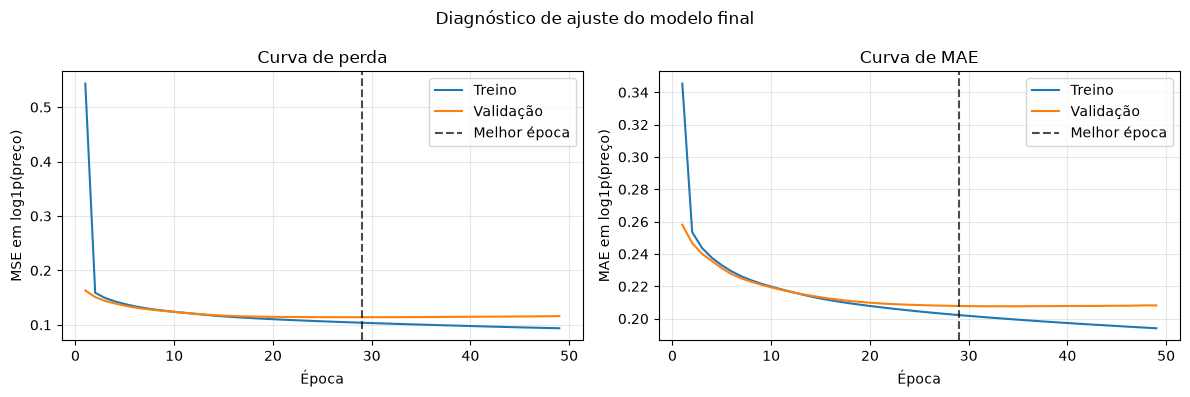

In [25]:
historico_final_df = pd.DataFrame(historico_final.history)
melhor_indice = int(historico_final_df['val_loss'].idxmin())
melhor_epoca = melhor_indice + 1
diagnostico_ajuste = pd.Series({
    'épocas treinadas': len(historico_final_df),
    'melhor época pela perda de validação': melhor_epoca,
    'MSE treino na melhor época': historico_final_df.loc[melhor_indice, 'loss'],
    'MSE validação na melhor época': historico_final_df.loc[melhor_indice, 'val_loss'],
    'MAE log treino na melhor época': historico_final_df.loc[melhor_indice, 'mae'],
    'MAE log validação na melhor época': historico_final_df.loc[melhor_indice, 'val_mae'],
})
display(diagnostico_ajuste.to_frame('resultado'))

epocas = np.arange(1, len(historico_final_df) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epocas, historico_final_df['loss'], label='Treino')
axes[0].plot(epocas, historico_final_df['val_loss'], label='Validação')
axes[0].axvline(melhor_epoca, color='black', linestyle='--', alpha=0.7, label='Melhor época')
axes[0].set(xlabel='Época', ylabel='MSE em log1p(preço)', title='Curva de perda')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(epocas, historico_final_df['mae'], label='Treino')
axes[1].plot(epocas, historico_final_df['val_mae'], label='Validação')
axes[1].axvline(melhor_epoca, color='black', linestyle='--', alpha=0.7, label='Melhor época')
axes[1].set(xlabel='Época', ylabel='MAE em log1p(preço)', title='Curva de MAE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
fig.suptitle('Diagnóstico de ajuste do modelo final')
plt.tight_layout(); plt.show()

A melhor época foi a 29. Nela, o MSE foi 0,10391 no treino e 0,11406 na validação, uma diferença de cerca de 9,8%; o MAE logarítmico foi 0,20223 e 0,20786, respectivamente.

Depois desse ponto, a perda de treino continuou diminuindo enquanto a validação ficou praticamente estável, com pequena elevação. Isso indica overfitting leve e tardio, não underfitting nem sobreajuste severo. Com paciência 20, o Early Stopping encerrou o treinamento na época 49 e restaurou os pesos da melhor época.

## 14. Conclusões gerais

A melhor configuração veio da Random Search: três camadas ocultas de 128, 128 e 64 neurônios, ativação `tanh`, Adam, learning rate de 0,000172, batch size 32 e paciência 20. Na validação cruzada, ela obteve MAE de US$ 2.383,38, RMSE de US$ 4.259,57 e R² de 0,8103.

No teste reservado, avaliado uma vez ao final, o modelo obteve MAE de US$ 2.083,09, RMSE de US$ 3.646,98 e R² de 0,8589. O resultado de teste foi compatível com a ordem de grandeza observada na validação e confirma capacidade de generalização para a divisão avaliada.

A Random Search venceu pelo melhor resultado individual; o TPE apresentou melhor média, mediana e estabilidade entre as 25 tentativas. Entre os hiperparâmetros analisados individualmente, `learning_rate` teve o maior impacto. O modelo mostrou overfitting leve após a época 29, controlado pelo Early Stopping.

A remoção de `mmr` torna a tarefa menos dependente de uma avaliação prévia de mercado. Já `idade_veiculo`, `color` e `interior` foram mantidos como informações complementares, junto às características técnicas e de uso dos veículos.

## 15. Referências técnicas e científicas

As referências abaixo documentam as APIs utilizadas e fundamentam as principais decisões metodológicas. Elas dão suporte à correção conceitual da implementação; a verificação empírica permanece registrada nas execuções, métricas, validação cruzada, teste reservado e análises de sensibilidade deste notebook. Links conferidos em **20 set. 2026**.

### Relação entre a implementação e as fontes

| Parte do trabalho | Como foi implementada | Fonte de verificação |
|---|---|---|
| MLP para regressão | Camadas densas e saída `Dense(1, activation='linear')` | Keras, documentação de `Dense` [1] |
| Treinamento e controle de sobreajuste | `EarlyStopping` monitorando `val_loss` e restaurando os melhores pesos | TensorFlow, documentação de `EarlyStopping` [2] |
| Dados heterogêneos | `ColumnTransformer`, imputação, `StandardScaler` e `OneHotEncoder` ajustados somente no fold de treino | scikit-learn, composição e pré-processamento [3–5] |
| Validação | `KFold` com três folds; cada fold atua uma vez como validação | scikit-learn, documentação de `KFold` [6] |
| Avaliação de regressão | MAE como critério principal, acompanhado de RMSE e R² | scikit-learn, métricas de regressão [7–9] |
| Random Search | Amostragem aleatória de configurações sob orçamento fixo | Bergstra e Bengio (2012) [10] |
| TPE | Otimização sequencial com `TPESampler` do Optuna e o mesmo orçamento da busca aleatória | Bergstra et al. (2011), Optuna 4.9 e Akiba et al. (2019) [11–13] |
| Origem dos dados | *Vehicle Sales and Market Trends Dataset* | Página do conjunto de dados no Kaggle [14] |

### Referências

1. KERAS. **Dense layer**. Keras API. Disponível em: <https://keras.io/api/layers/core_layers/dense/>. Acesso em: 20 set. 2026.
2. TENSORFLOW. **tf.keras.callbacks.EarlyStopping**. TensorFlow API. Disponível em: <https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping>. Acesso em: 20 set. 2026.
3. SCIKIT-LEARN. **Pipelines and composite estimators**. Versão 1.5.2. Disponível em: <https://scikit-learn.org/1.5/modules/compose.html>. Acesso em: 20 set. 2026.
4. SCIKIT-LEARN. **ColumnTransformer**. Versão 1.5.2. Disponível em: <https://scikit-learn.org/1.5/modules/generated/sklearn.compose.ColumnTransformer.html>. Acesso em: 20 set. 2026.
5. SCIKIT-LEARN. **Preprocessing data**. Versão 1.5.2. Disponível em: <https://scikit-learn.org/1.5/modules/preprocessing.html>. Acesso em: 20 set. 2026.
6. SCIKIT-LEARN. **KFold**. Versão 1.5.2. Disponível em: <https://scikit-learn.org/1.5/modules/generated/sklearn.model_selection.KFold.html>. Acesso em: 20 set. 2026.
7. SCIKIT-LEARN. **mean_absolute_error**. Versão 1.5.2. Disponível em: <https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.mean_absolute_error.html>. Acesso em: 20 set. 2026.
8. SCIKIT-LEARN. **root_mean_squared_error**. Versão 1.5.2. Disponível em: <https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.root_mean_squared_error.html>. Acesso em: 20 set. 2026.
9. SCIKIT-LEARN. **r2_score**. Versão 1.5.2. Disponível em: <https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.r2_score.html>. Acesso em: 20 set. 2026.
10. BERGSTRA, J.; BENGIO, Y. **Random Search for Hyper-Parameter Optimization**. *Journal of Machine Learning Research*, v. 13, p. 281–305, 2012. Disponível em: <https://jmlr.org/papers/v13/bergstra12a.html>.
11. BERGSTRA, J.; BARDENET, R.; BENGIO, Y.; KÉGL, B. **Algorithms for Hyper-Parameter Optimization**. *Advances in Neural Information Processing Systems 24*, 2011. Disponível em: <https://papers.nips.cc/paper/4443-algorithms-for-hyper-parameter-optimization>.
12. OPTUNA. **Efficient Optimization Algorithms: TPESampler**. Documentação da versão 4.9.0. Disponível em: <https://optuna.readthedocs.io/en/v4.9.0/tutorial/10_key_features/003_efficient_optimization_algorithms.html>. Acesso em: 20 set. 2026.
13. AKIBA, T.; SANO, S.; YANASE, T.; OHTA, T.; KOYAMA, M. **Optuna: A Next-generation Hyperparameter Optimization Framework**. In: *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining*, p. 2623–2631, 2019. DOI: <https://doi.org/10.1145/3292500.3330701>.
14. AFRIDI, S. A. **Vehicle Sales and Market Trends Dataset**. Kaggle. Disponível em: <https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data>. Acesso em: 20 set. 2026.
